In [60]:
# Core
import json
import numpy as np
import pandas as pd
import joblib
import random

# Visualization (unchanged)
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# PyTorch (replaces TensorFlow/Keras)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [61]:
# Device setup (PyTorch equivalent of TF GPU check)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)

Using device: cuda
GPU Name: NVIDIA GeForce GTX 1650
CUDA Version: 13.0


In [62]:
import matplotlib as mpl

mpl.rcParams["figure.dpi"] = 200        # notebook display
mpl.rcParams["savefig.dpi"] = 600       # exported figures
mpl.rcParams["figure.figsize"] = (8, 6)
mpl.rcParams["axes.titlesize"] = 14
mpl.rcParams["axes.labelsize"] = 12
mpl.rcParams["xtick.labelsize"] = 10
mpl.rcParams["ytick.labelsize"] = 10

In [63]:
X_test = np.load("../data/processed/X_test.npy")
y_scaler = joblib.load("../data/processed/y_scaler.pkl")
y_test = np.load("../data/processed/y_test.npy")
Z_test = np.load("../data/interim/Z_test.npy")

In [64]:
class FinalParkinsonNN(nn.Module):
    def __init__(self, params, input_dim=18):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, params["units_l1"]), nn.ReLU(),
            nn.Linear(params["units_l1"], params["units_l2"]), nn.ReLU(),
            nn.Dropout(params["dropout"]),
            nn.Linear(params["units_l2"], params["units_l3"]), nn.ReLU(),
            nn.Linear(params["units_l3"], params["units_l4"]), nn.ReLU(),
            nn.Linear(params["units_l4"], 2)
        )

    def forward(self, x):
        return self.net(x)

In [65]:
with open("../models/best_nn_params.json", "r") as f:
    params = json.load(f)

In [66]:
nn_model = FinalParkinsonNN(params).to(DEVICE)
nn_model.load_state_dict(torch.load("../models/best_nn_model.pt"))
nn_model.eval()

FinalParkinsonNN(
  (net): Sequential(
    (0): Linear(in_features=18, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Dropout(p=0.0003447602204319656, inplace=False)
    (5): Linear(in_features=64, out_features=64, bias=True)
    (6): ReLU()
    (7): Linear(in_features=64, out_features=32, bias=True)
    (8): ReLU()
    (9): Linear(in_features=32, out_features=2, bias=True)
  )
)

In [67]:
class MoEGate(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=32, n_experts=4):
        super().__init__()
        
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        
        # Separate heads for motor and total
        self.motor_head = nn.Linear(hidden_dim, n_experts)
        self.total_head = nn.Linear(hidden_dim, n_experts)

    def forward(self, z):
        x = self.shared(z)

        motor_weights = F.softmax(self.motor_head(x), dim=1)
        total_weights = F.softmax(self.total_head(x), dim=1)

        return motor_weights, total_weights

In [68]:
def moe_forward(gate, z, n_experts=4):
    
    motor_w, total_w = gate(z)

    # Split expert predictions
    experts = z.view(-1, n_experts, 2)

    motor_preds = experts[:, :, 0]
    total_preds = experts[:, :, 1]

    motor_out = torch.sum(motor_w * motor_preds, dim=1)
    total_out = torch.sum(total_w * total_preds, dim=1)

    return torch.stack([motor_out, total_out], dim=1)

In [69]:
gate_model = MoEGate(input_dim=8, hidden_dim=32, n_experts=4).to(DEVICE)
gate_model.load_state_dict(torch.load("../models/best_gate.pt"))
gate_model.eval()

MoEGate(
  (shared): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
  )
  (motor_head): Linear(in_features=32, out_features=4, bias=True)
  (total_head): Linear(in_features=32, out_features=4, bias=True)
)

In [70]:
rf_expert = joblib.load("../models/rf_expert.pkl")
ridge_expert = joblib.load("../models/ridge_expert.pkl")
enet_expert = joblib.load("../models/enet_expert.pkl")

In [71]:
def evaluate_model(name, y_true, y_pred):
    r2_motor = r2_score(y_true[:, 0], y_pred[:, 0])
    r2_total = r2_score(y_true[:, 1], y_pred[:, 1])
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    avg_r2 = (r2_motor + r2_total) / 2
    
    return {
        "Model": name,
        "Motor R2": r2_motor,
        "Total R2": r2_total,
        "Avg R2": avg_r2,
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse
    }

In [72]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
Z_test_tensor = torch.tensor(Z_test, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    nn_preds_scaled = nn_model(X_test_tensor).cpu().numpy()
    moe_preds_scaled = moe_forward(gate_model, Z_test_tensor).cpu().numpy()

rf_preds_scaled = rf_expert.predict(X_test)
ridge_preds_scaled = ridge_expert.predict(X_test)
enet_preds_scaled = enet_expert.predict(X_test)

nn_preds = y_scaler.inverse_transform(nn_preds_scaled)
rf_preds = y_scaler.inverse_transform(rf_preds_scaled)
ridge_preds = y_scaler.inverse_transform(ridge_preds_scaled)
enet_preds = y_scaler.inverse_transform(enet_preds_scaled)
moe_preds = y_scaler.inverse_transform(moe_preds_scaled)

In [73]:
results = []

results.append(evaluate_model("Ridge", y_test, ridge_preds))
results.append(evaluate_model("ElasticNet", y_test, enet_preds))
results.append(evaluate_model("Random Forest", y_test, rf_preds))
results.append(evaluate_model("Neural Network", y_test, nn_preds))
results.append(evaluate_model("MoE (Entropy)", y_test, moe_preds))

results_df = pd.DataFrame(results)
results_df = results_df.sort_values("Avg R2", ascending=False)

results_df

,Model,Motor R2,Total R2,Avg R2,RMSE,MAE,MSE
2,Random Forest,0.913103,0.923716,0.918409,2.645738,1.908904,6.999930
4,MoE (Entropy),0.908844,0.917667,0.913255,2.733316,1.974003,7.471015
3,Neural Network,0.893488,0.903920,0.898704,2.953436,2.189383,8.722786
0,Ridge,0.115655,0.151379,0.133517,8.674255,7.207309,75.242704
1,ElasticNet,0.114231,0.151878,0.133055,8.675278,7.209550,75.260454


In [74]:
results_df_rounded = results_df.copy()

for col in ["Motor R2", "Total R2", "Avg R2"]:
    results_df_rounded[col] = results_df_rounded[col].round(4)

for col in ["RMSE", "MAE", "MSE"]:
    results_df_rounded[col] = results_df_rounded[col].round(4)

results_df_rounded

,Model,Motor R2,Total R2,Avg R2,RMSE,MAE,MSE
2,Random Forest,0.9131,0.9237,0.9184,2.6457,1.9089,6.9999
4,MoE (Entropy),0.9088,0.9177,0.9133,2.7333,1.9740,7.4710
3,Neural Network,0.8935,0.9039,0.8987,2.9534,2.1894,8.7228
0,Ridge,0.1157,0.1514,0.1335,8.6743,7.2073,75.2427
1,ElasticNet,0.1142,0.1519,0.1331,8.6753,7.2096,75.2605


In [75]:
results_df_rounded.to_csv("../results/performance_comparison.csv", index=False)

latex_table = results_df_rounded.to_latex(index=False)
with open("../results/performance_table.tex", "w") as f:
    f.write(latex_table)

In [76]:
def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(6,6))
    
    plt.scatter(y_true, y_pred, alpha=0.4)
    
    # Identity line
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')
    
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"../results/{title.replace(' ', '_').lower()}_actual_vs_pred.png")
    plt.show()

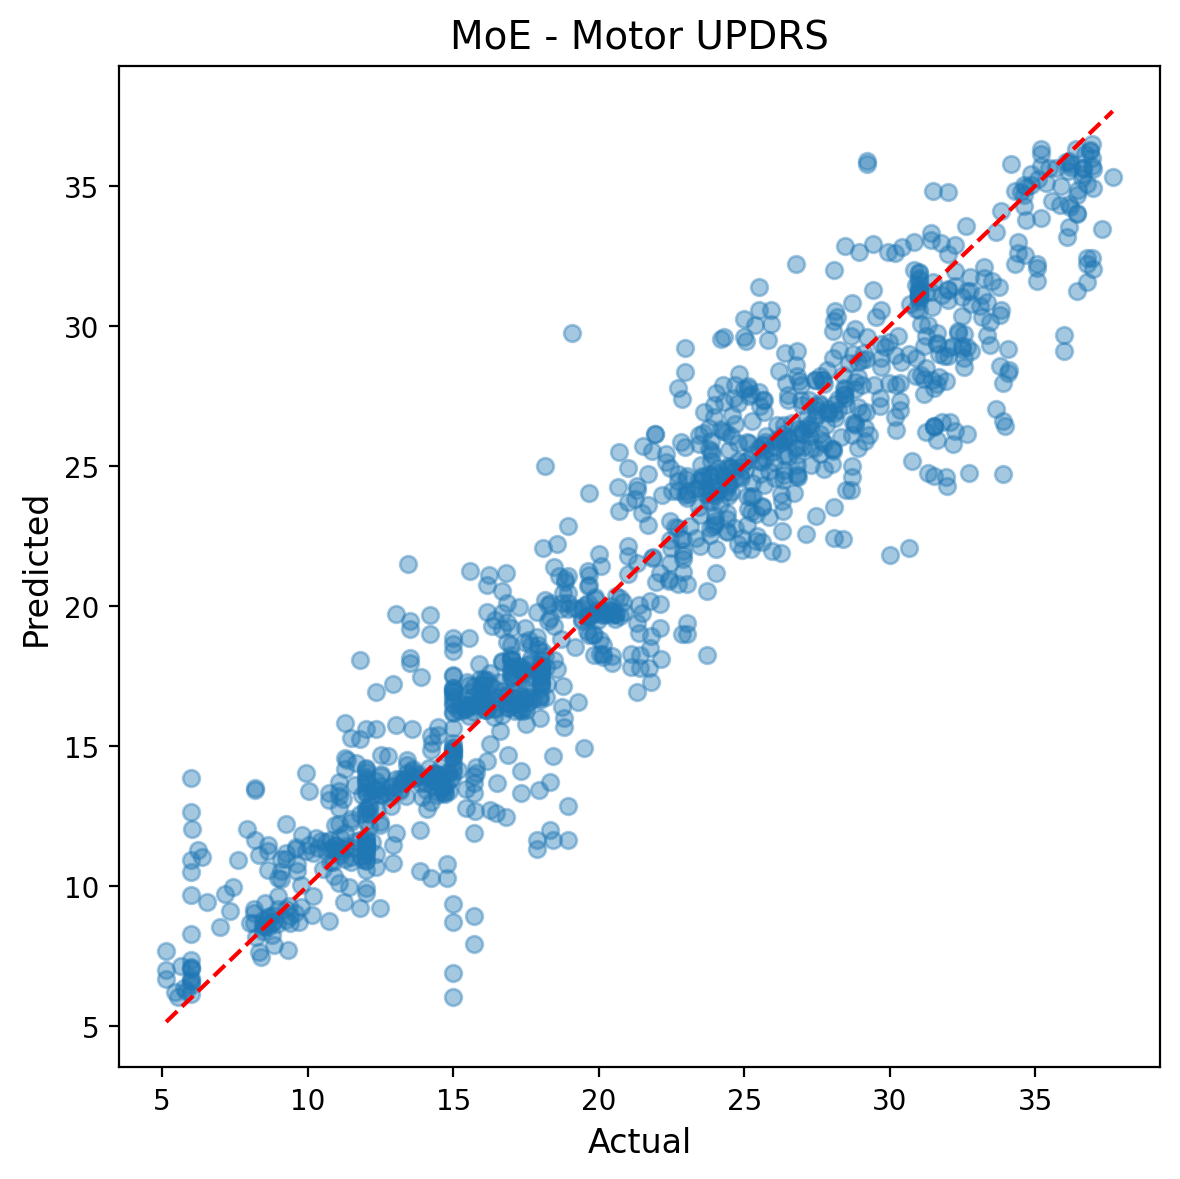

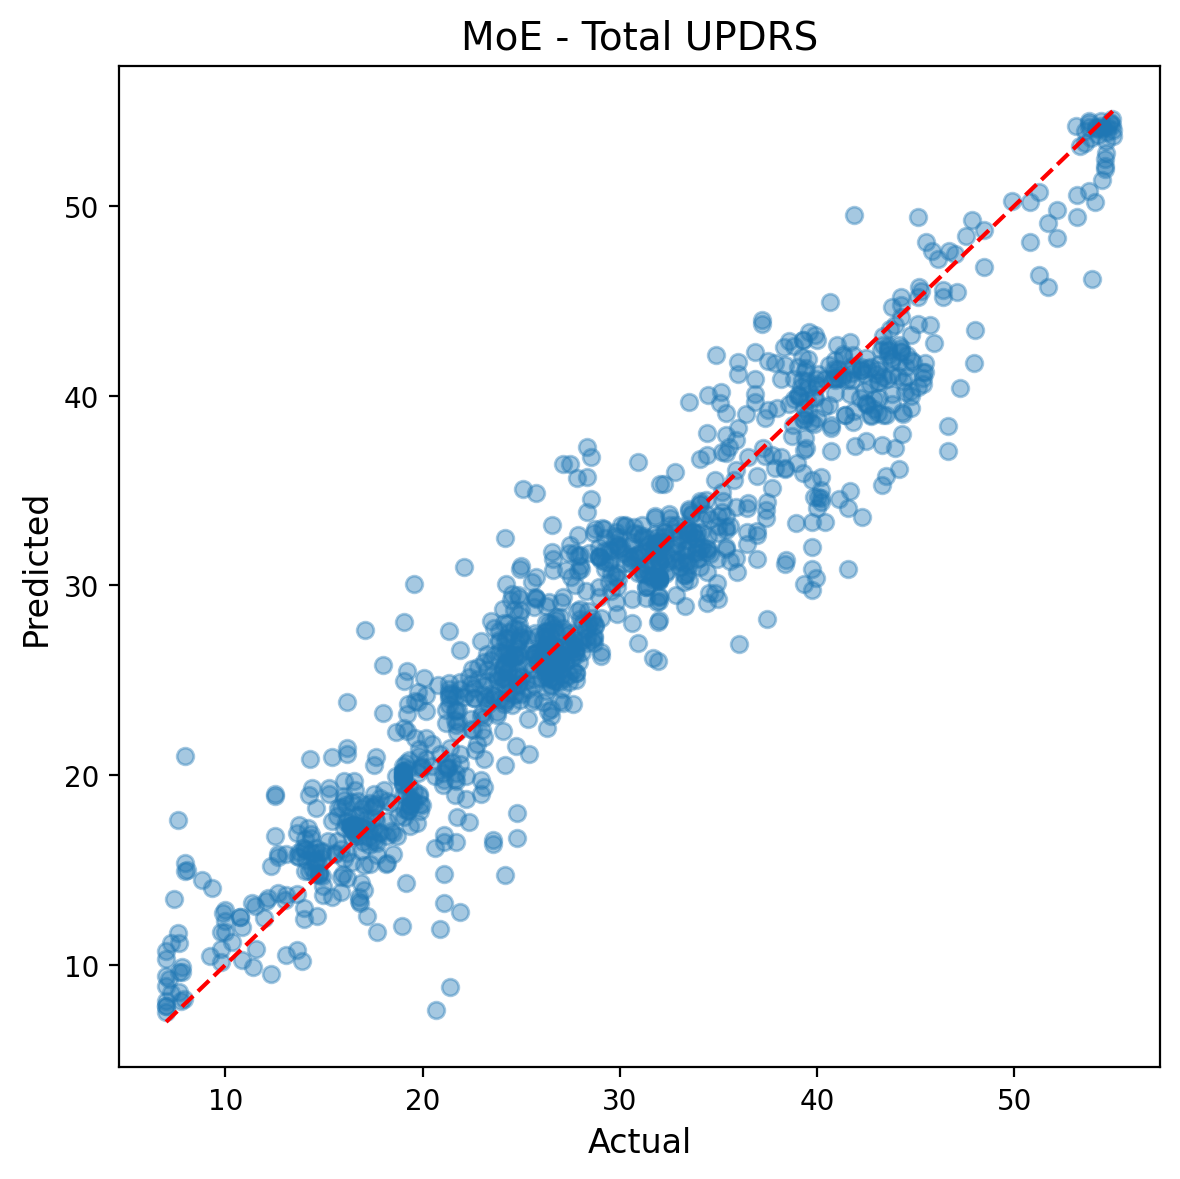

In [77]:
plot_actual_vs_pred(y_test[:,0], moe_preds[:,0], "MoE - Motor UPDRS")
plot_actual_vs_pred(y_test[:,1], moe_preds[:,1], "MoE - Total UPDRS")

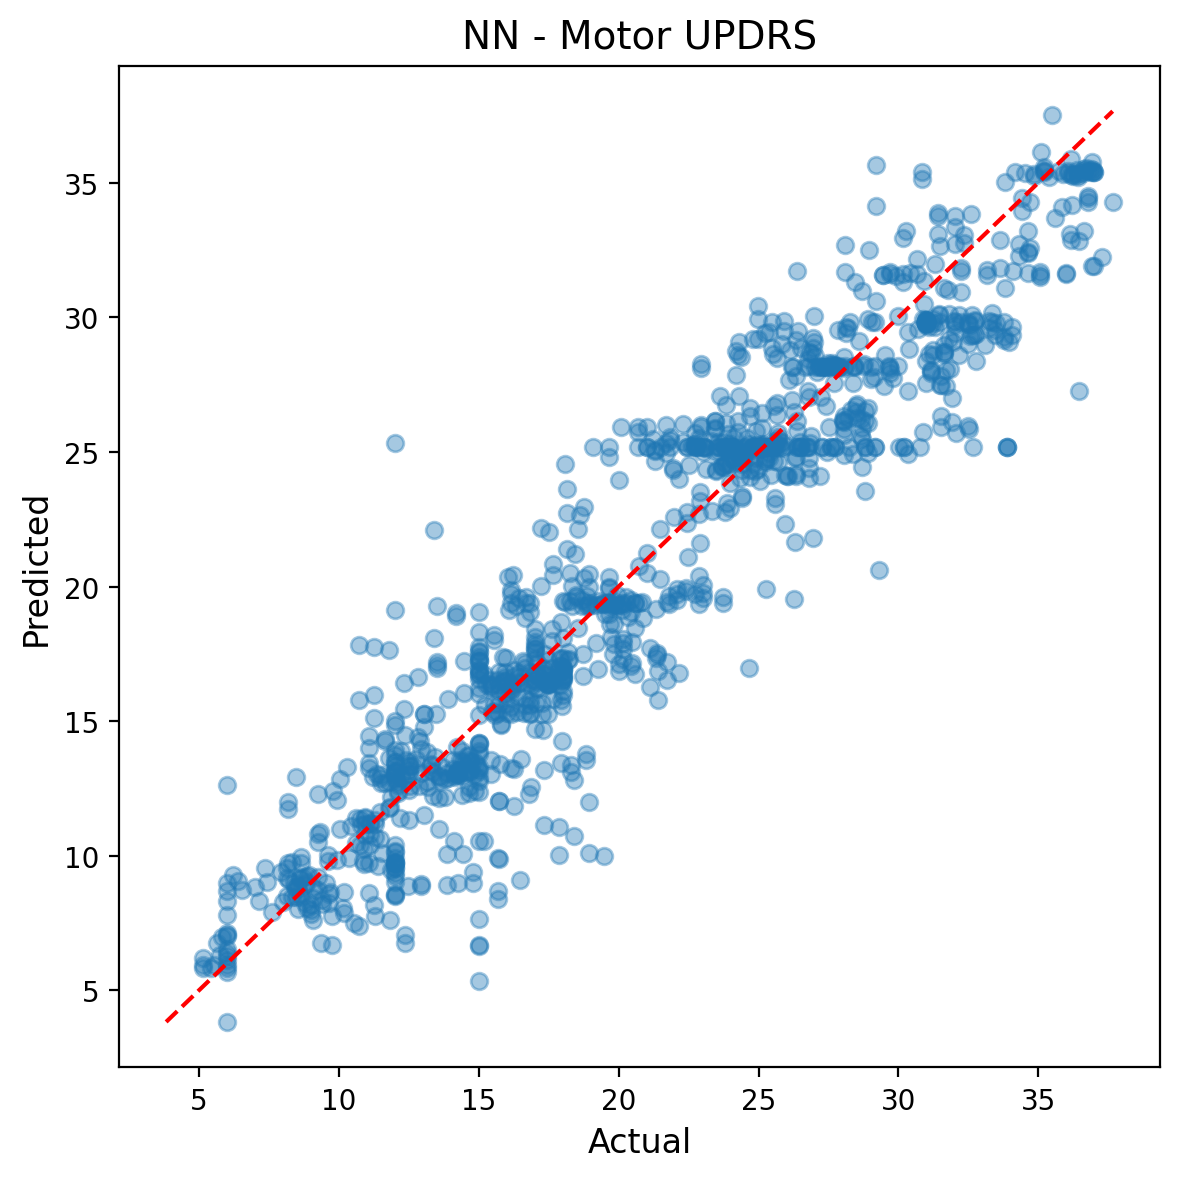

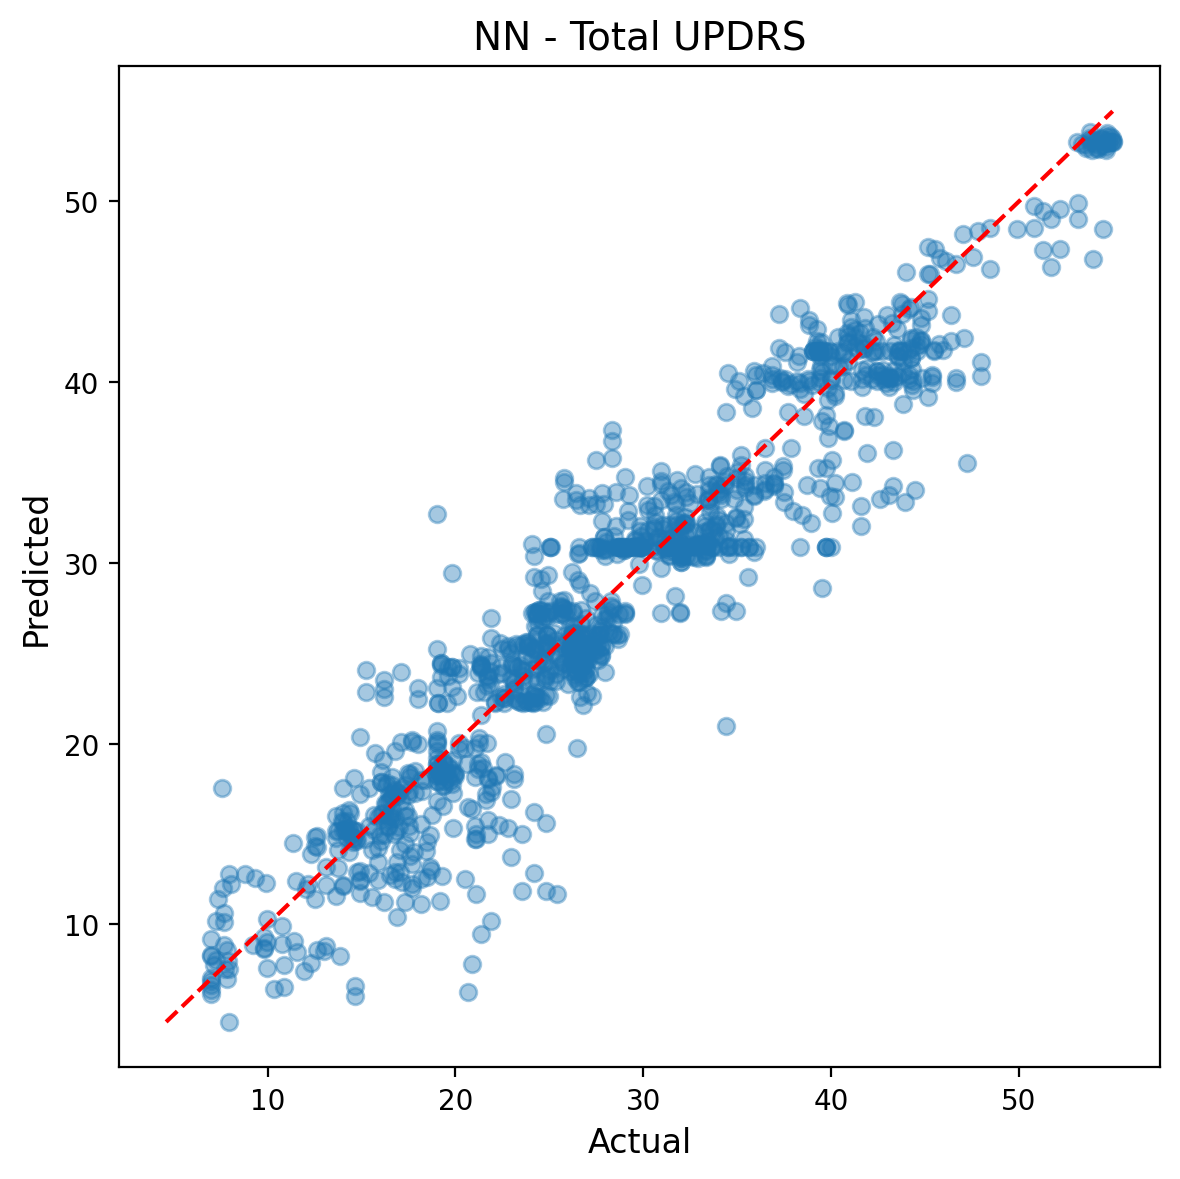

In [78]:
plot_actual_vs_pred(y_test[:,0], nn_preds[:,0], "NN - Motor UPDRS")
plot_actual_vs_pred(y_test[:,1], nn_preds[:,1], "NN - Total UPDRS")

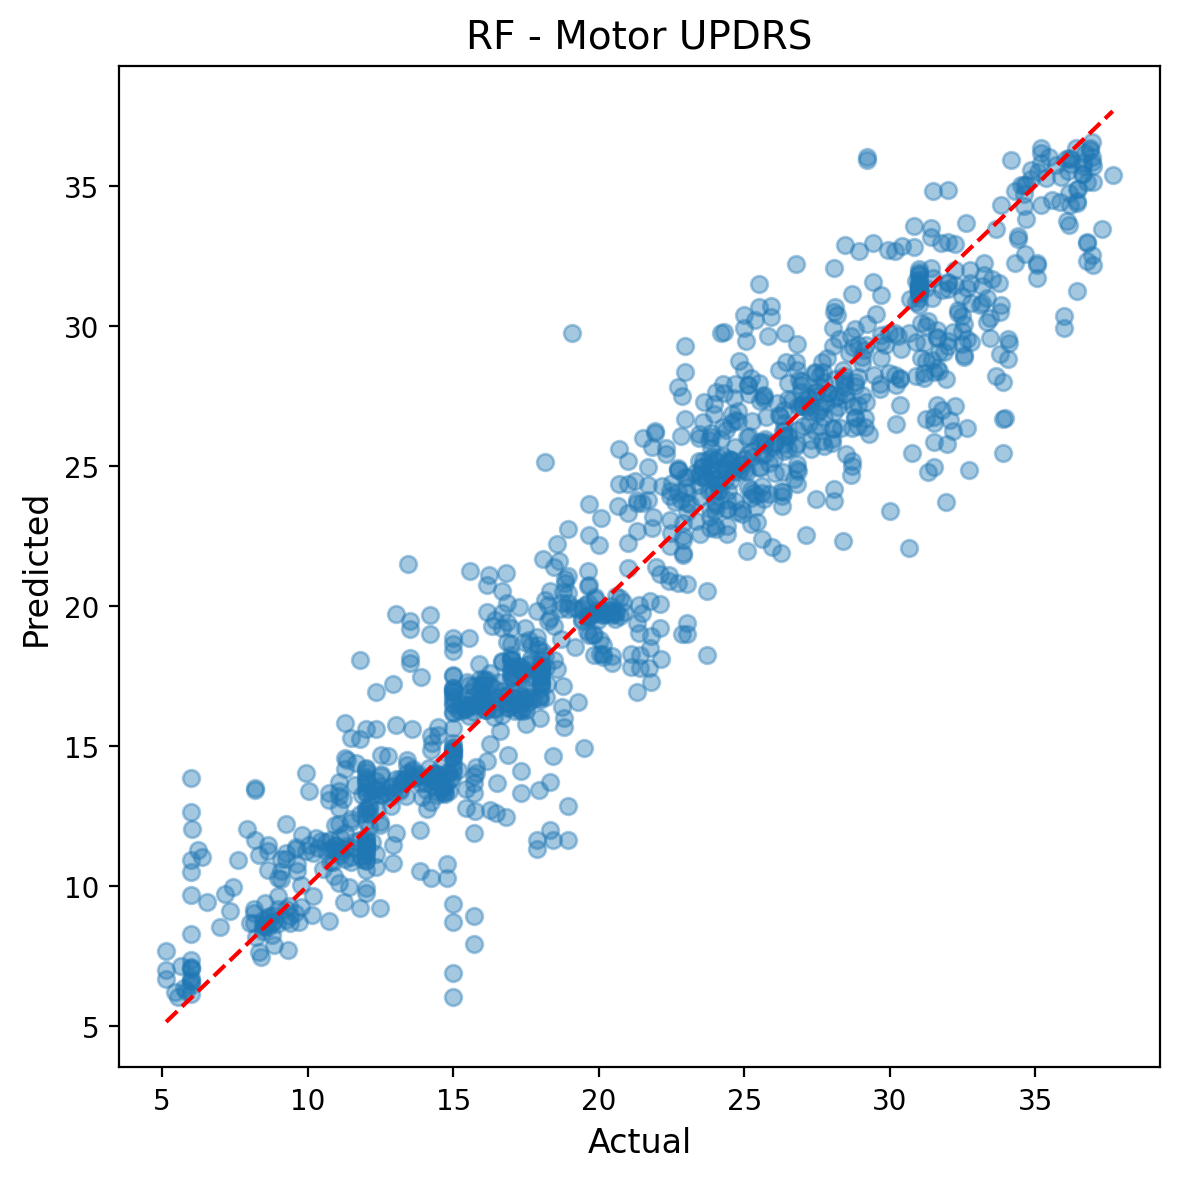

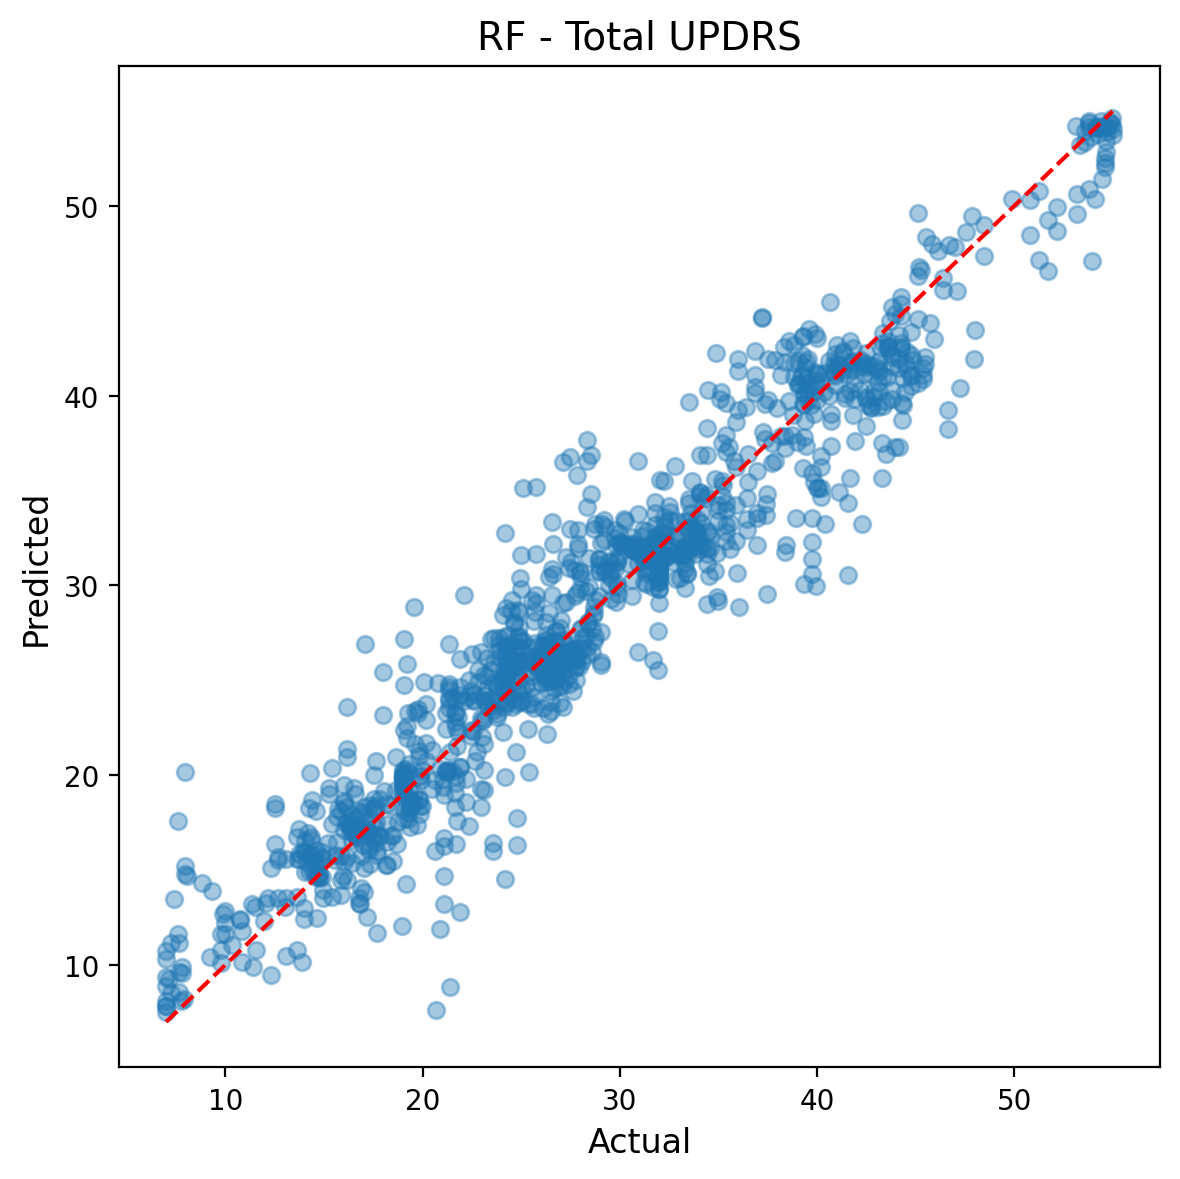

In [79]:
plot_actual_vs_pred(y_test[:,0], rf_preds[:,0], "RF - Motor UPDRS")
plot_actual_vs_pred(y_test[:,1], rf_preds[:,1], "RF - Total UPDRS")

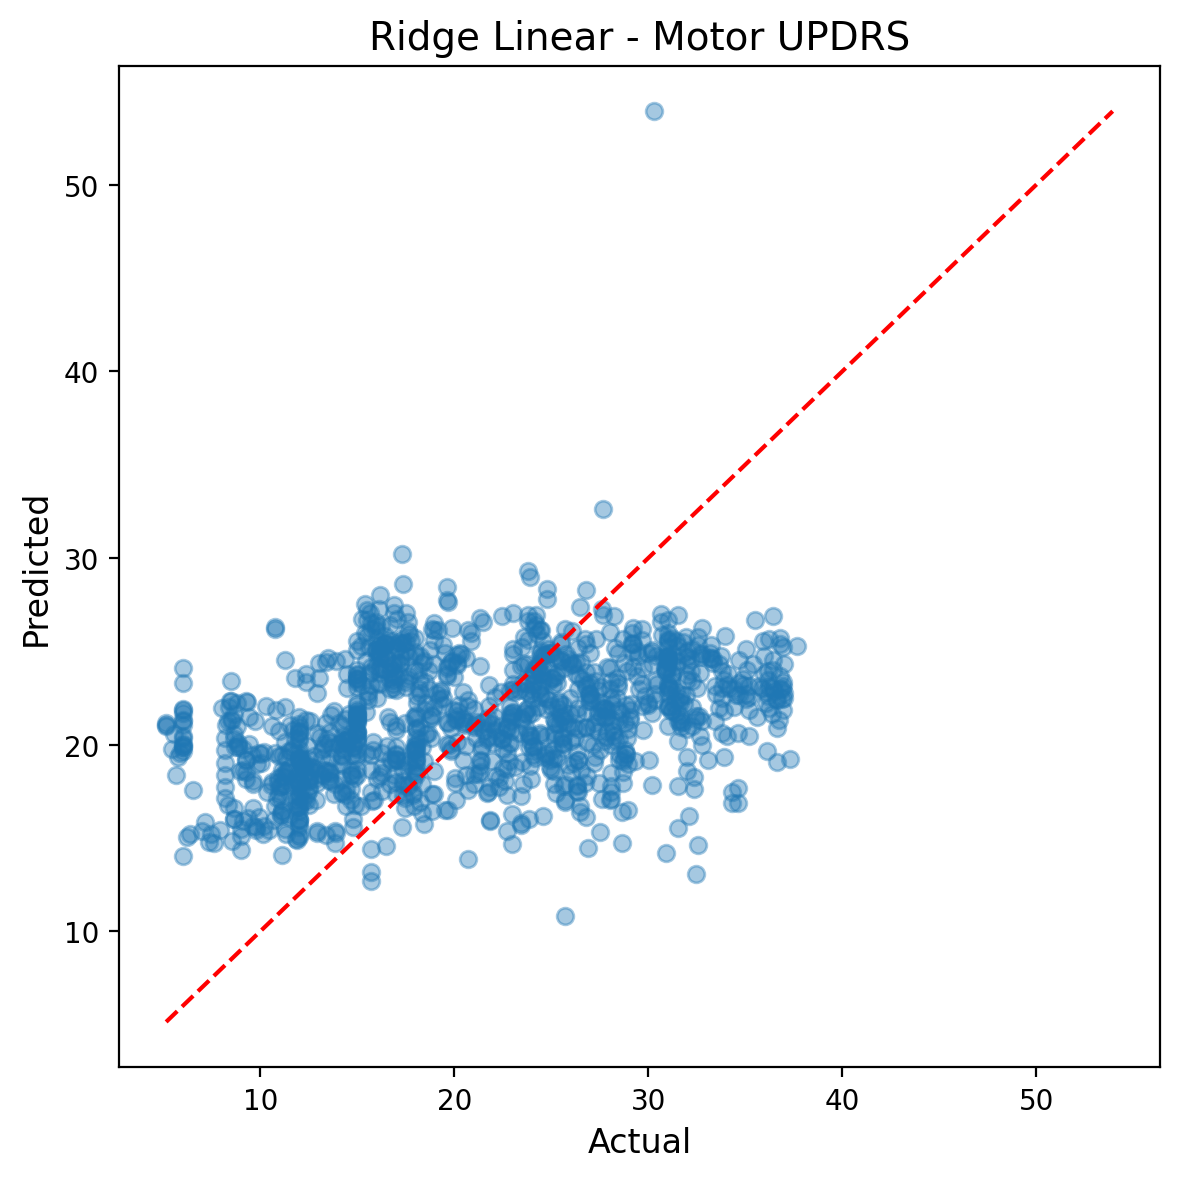

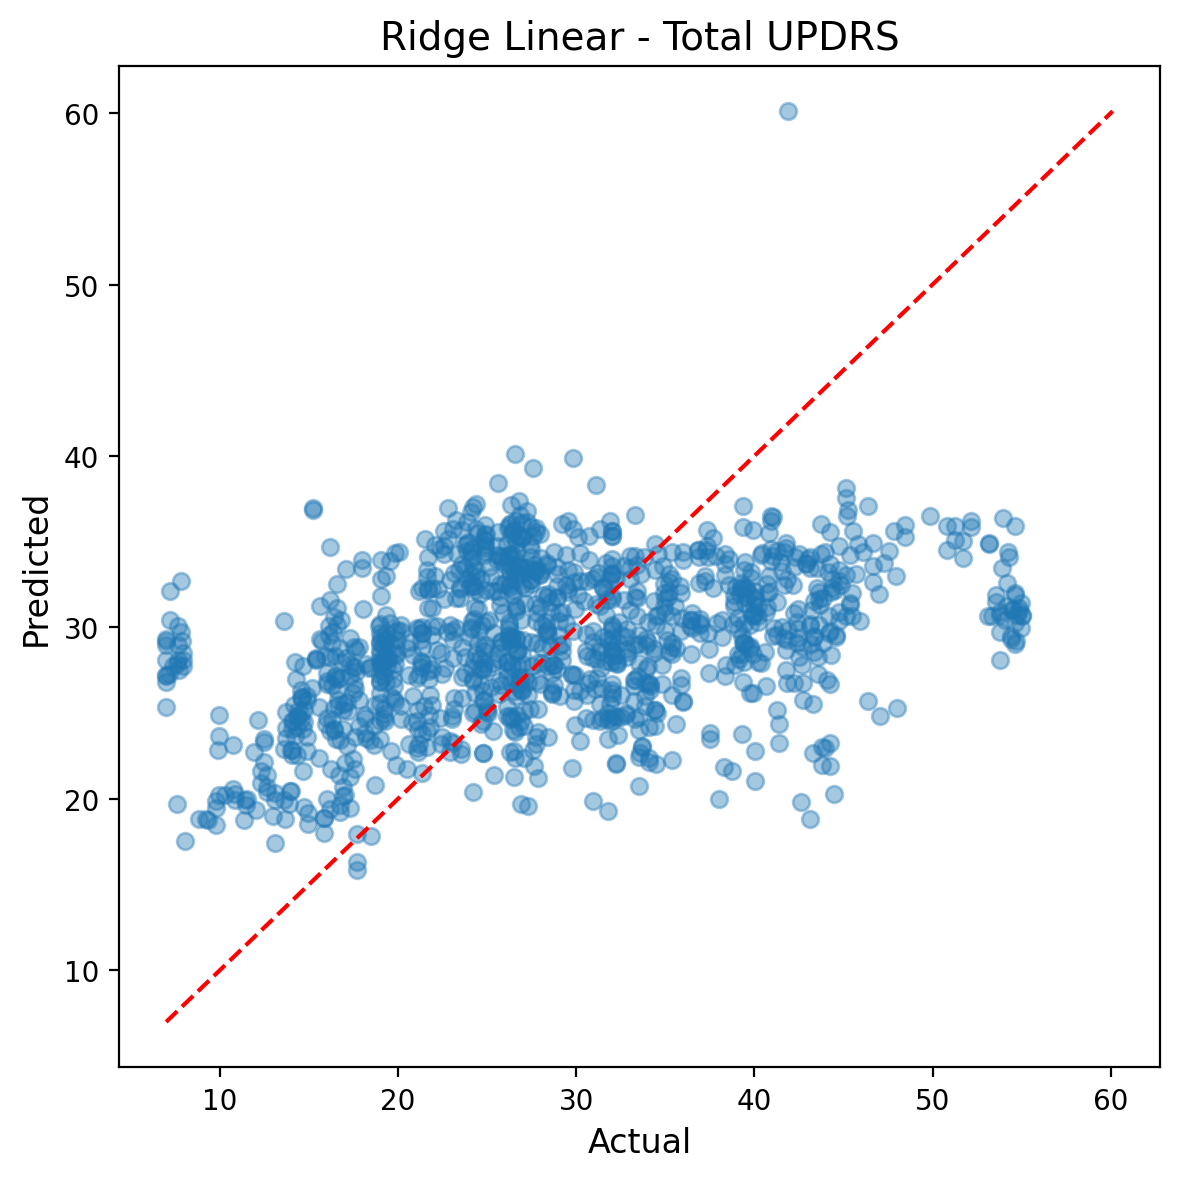

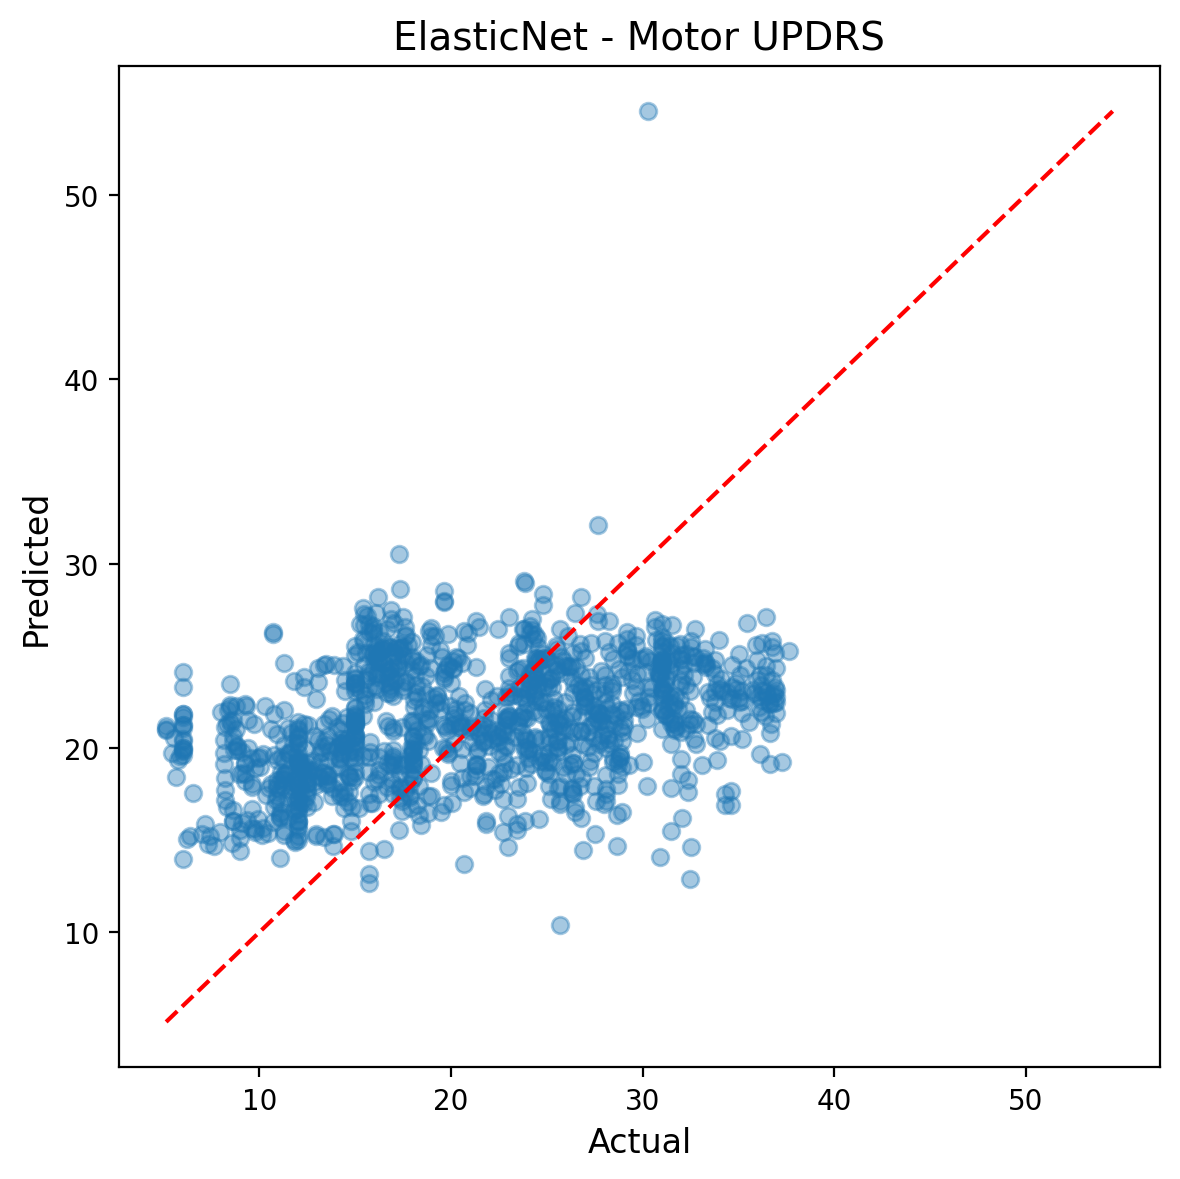

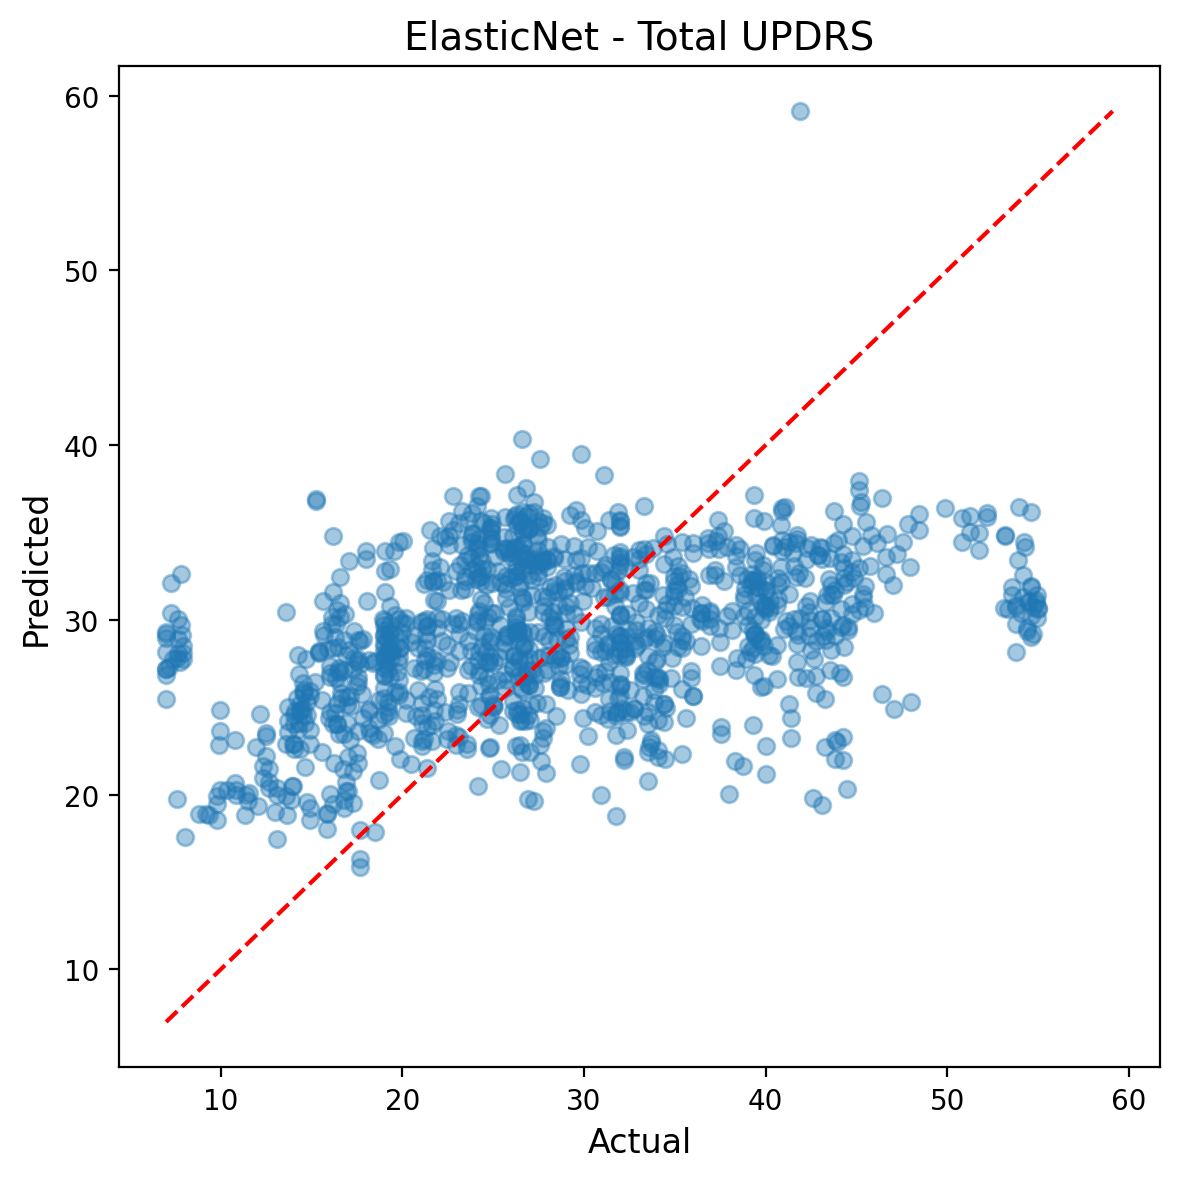

In [80]:
plot_actual_vs_pred(y_test[:,0], ridge_preds[:,0], "Ridge Linear - Motor UPDRS")
plot_actual_vs_pred(y_test[:,1], ridge_preds[:,1], "Ridge Linear - Total UPDRS")

plot_actual_vs_pred(y_test[:,0], enet_preds[:,0], "ElasticNet - Motor UPDRS")
plot_actual_vs_pred(y_test[:,1], enet_preds[:,1], "ElasticNet - Total UPDRS")

In [81]:
def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(6,5))
    plt.scatter(y_pred, residuals, alpha=0.4)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"../results/{title.replace(' ', '_').lower()}_residuals.png")
    plt.show()

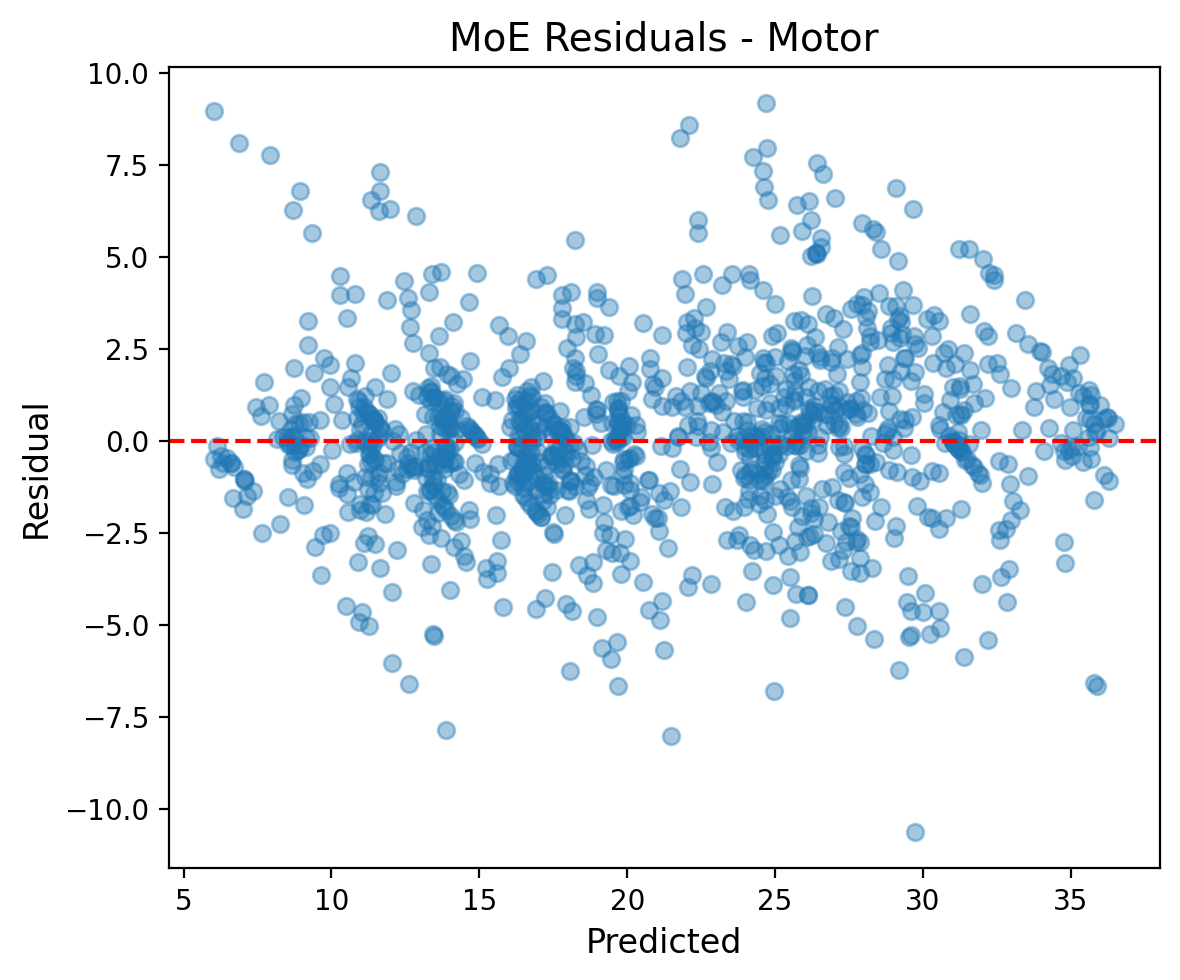

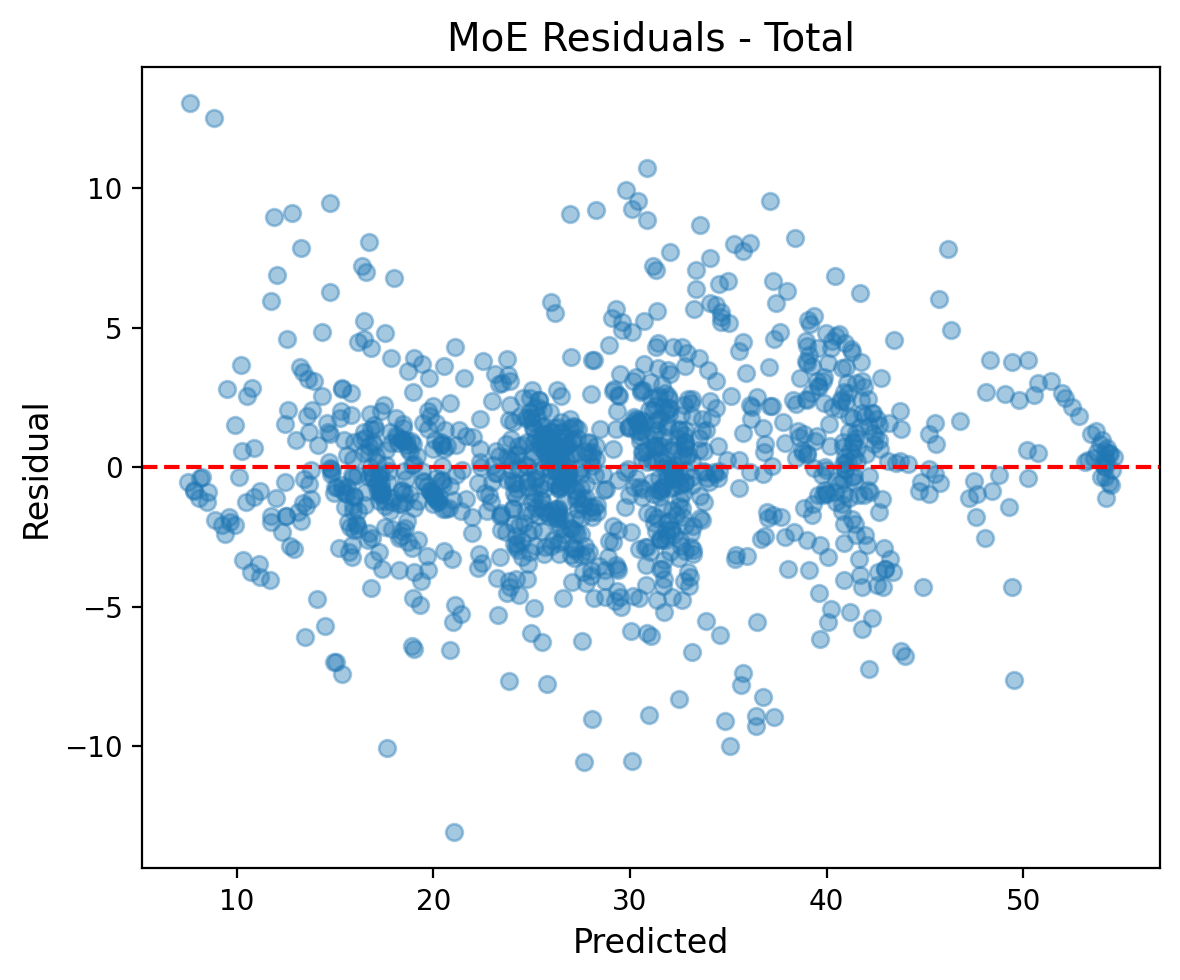

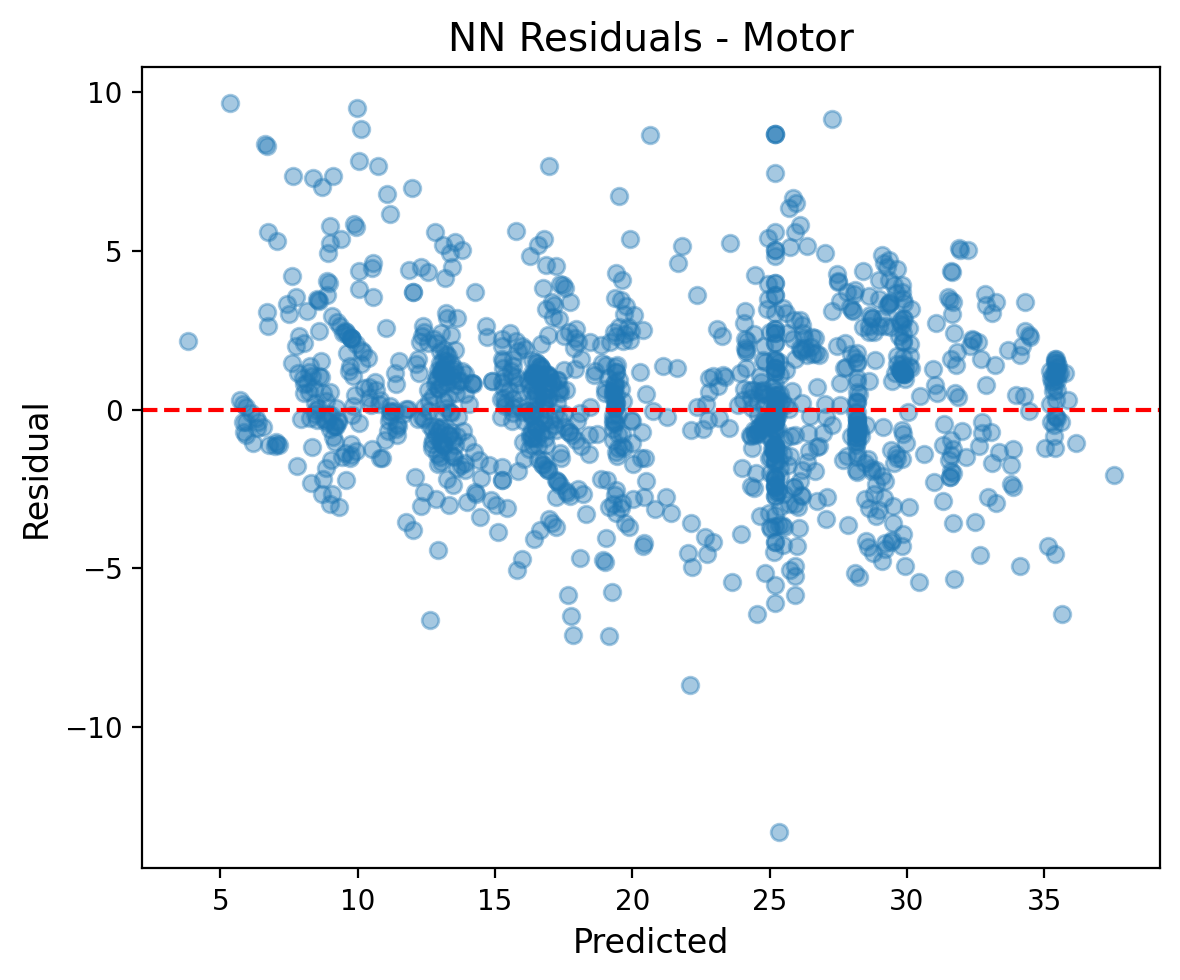

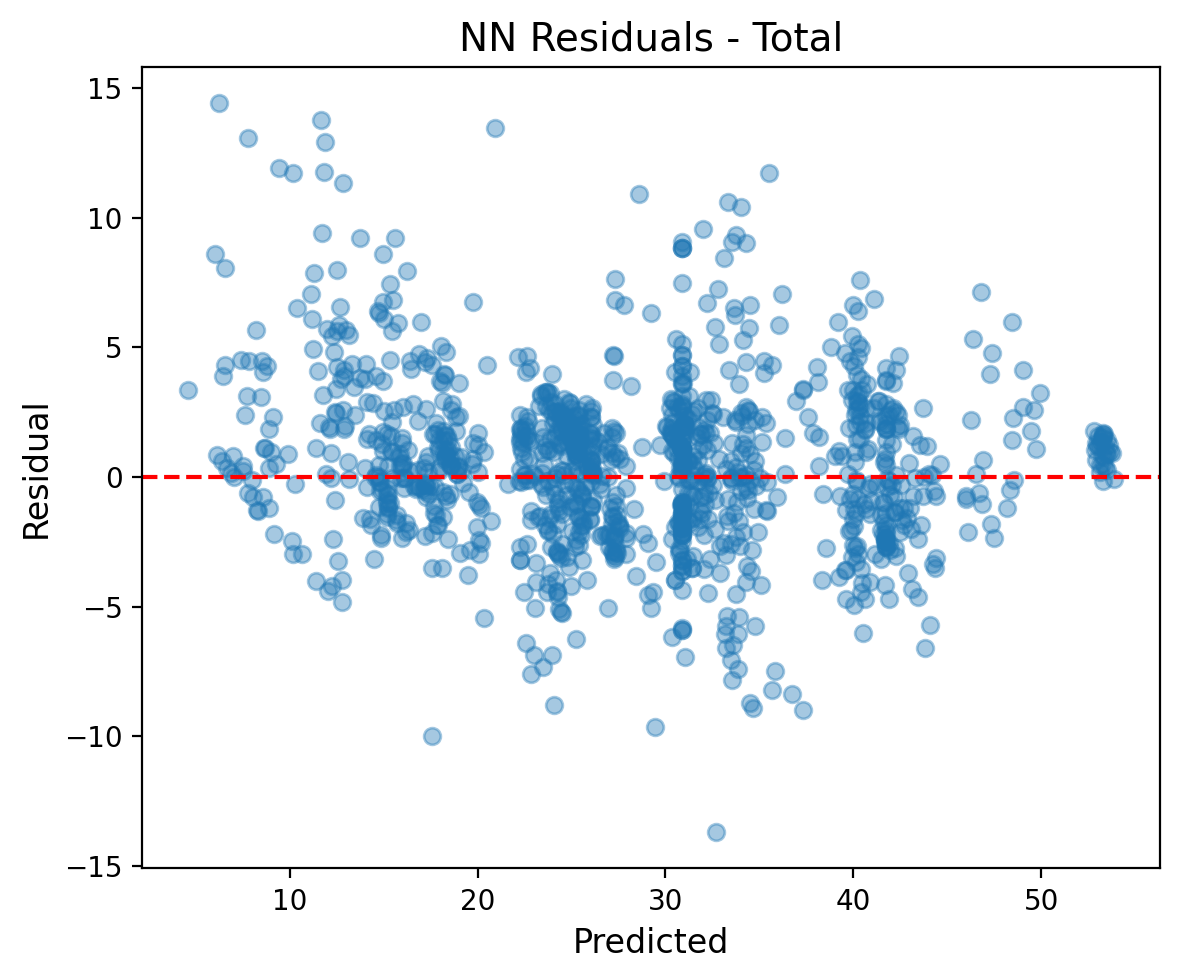

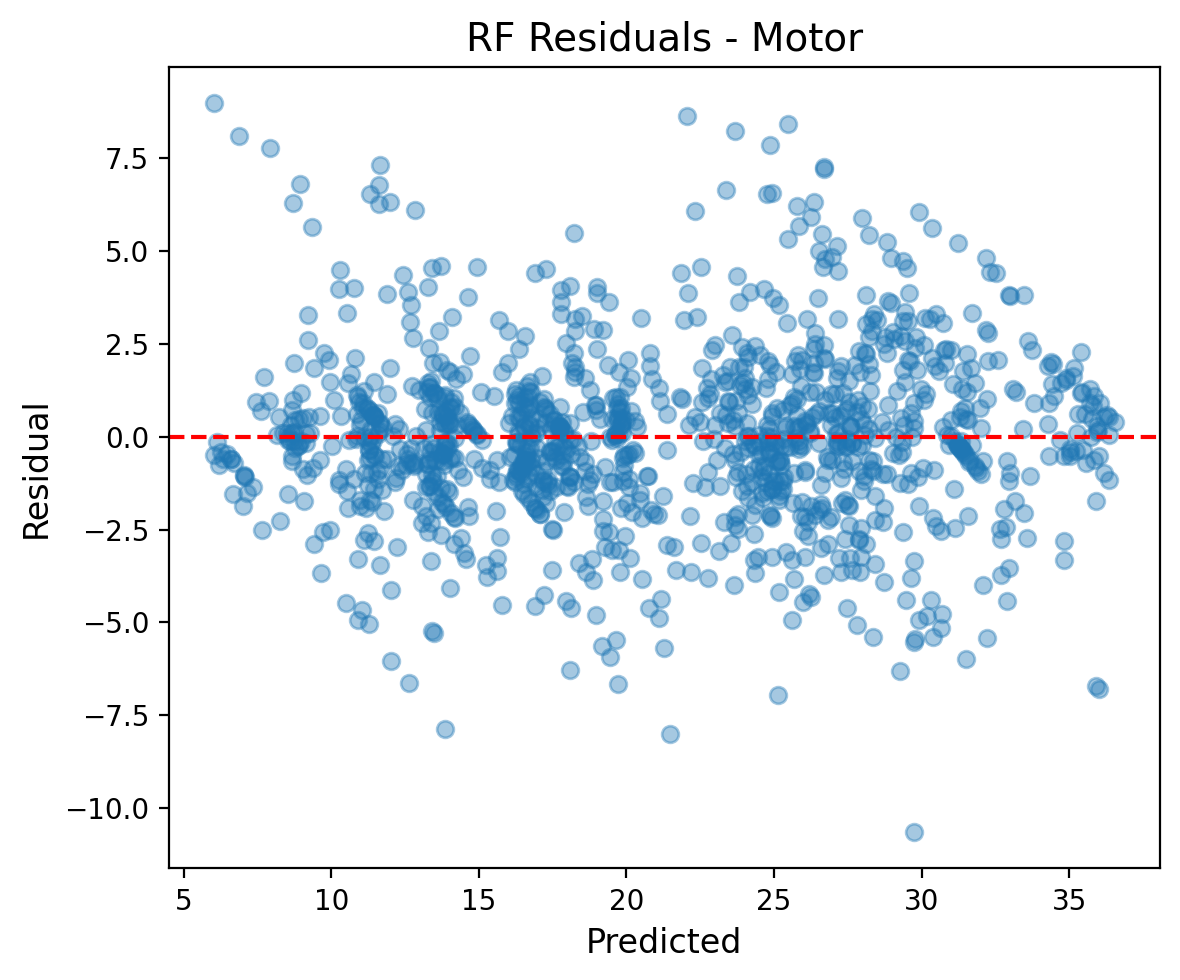

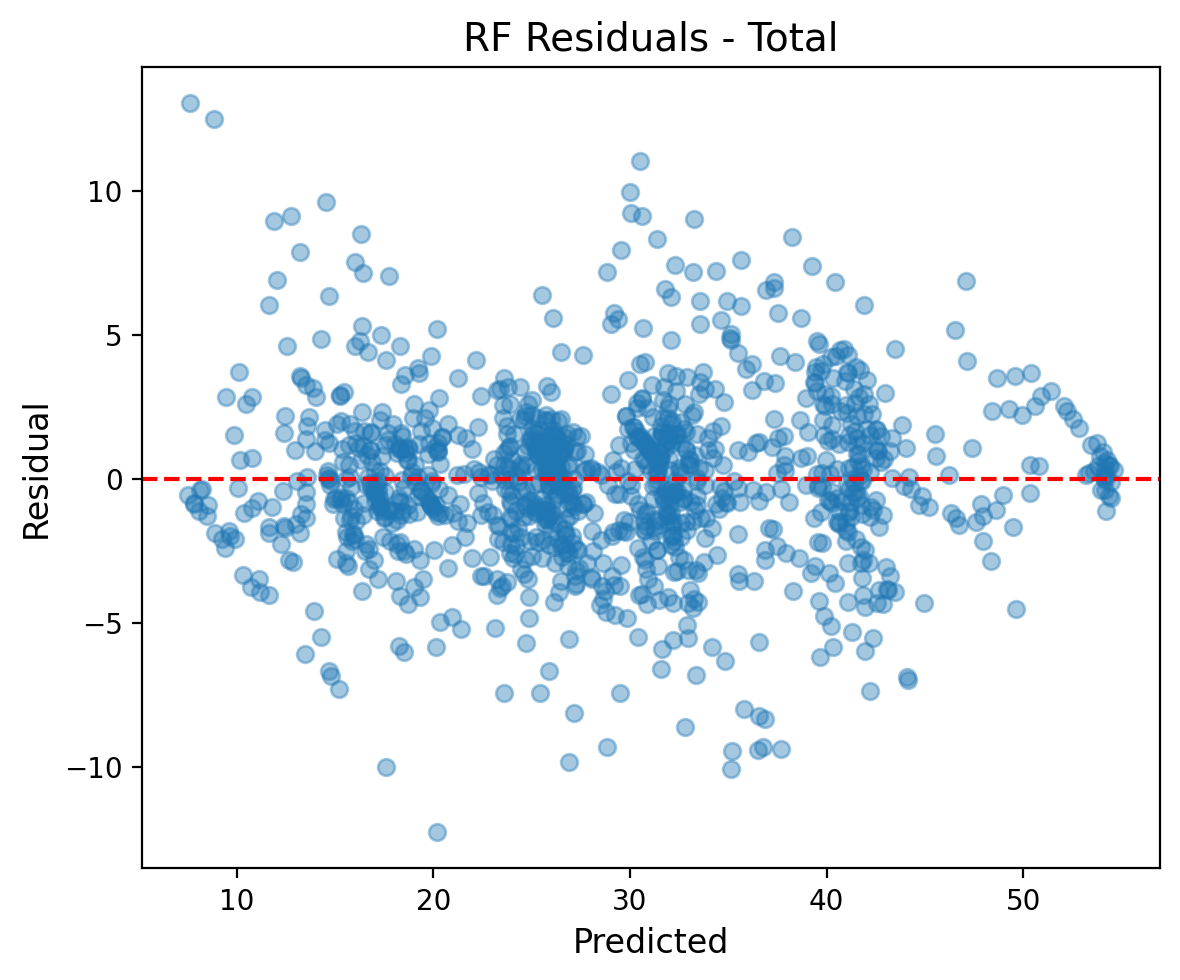

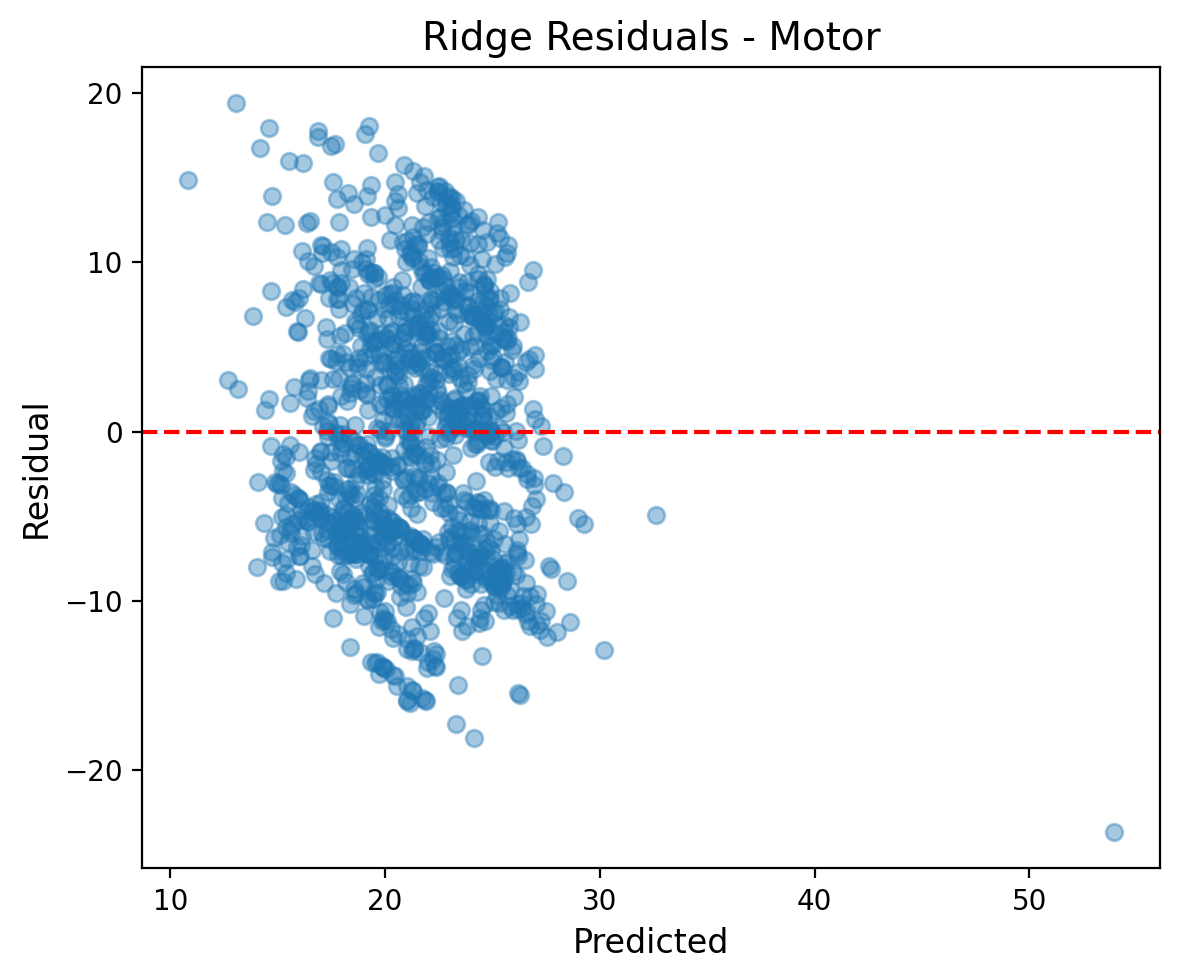

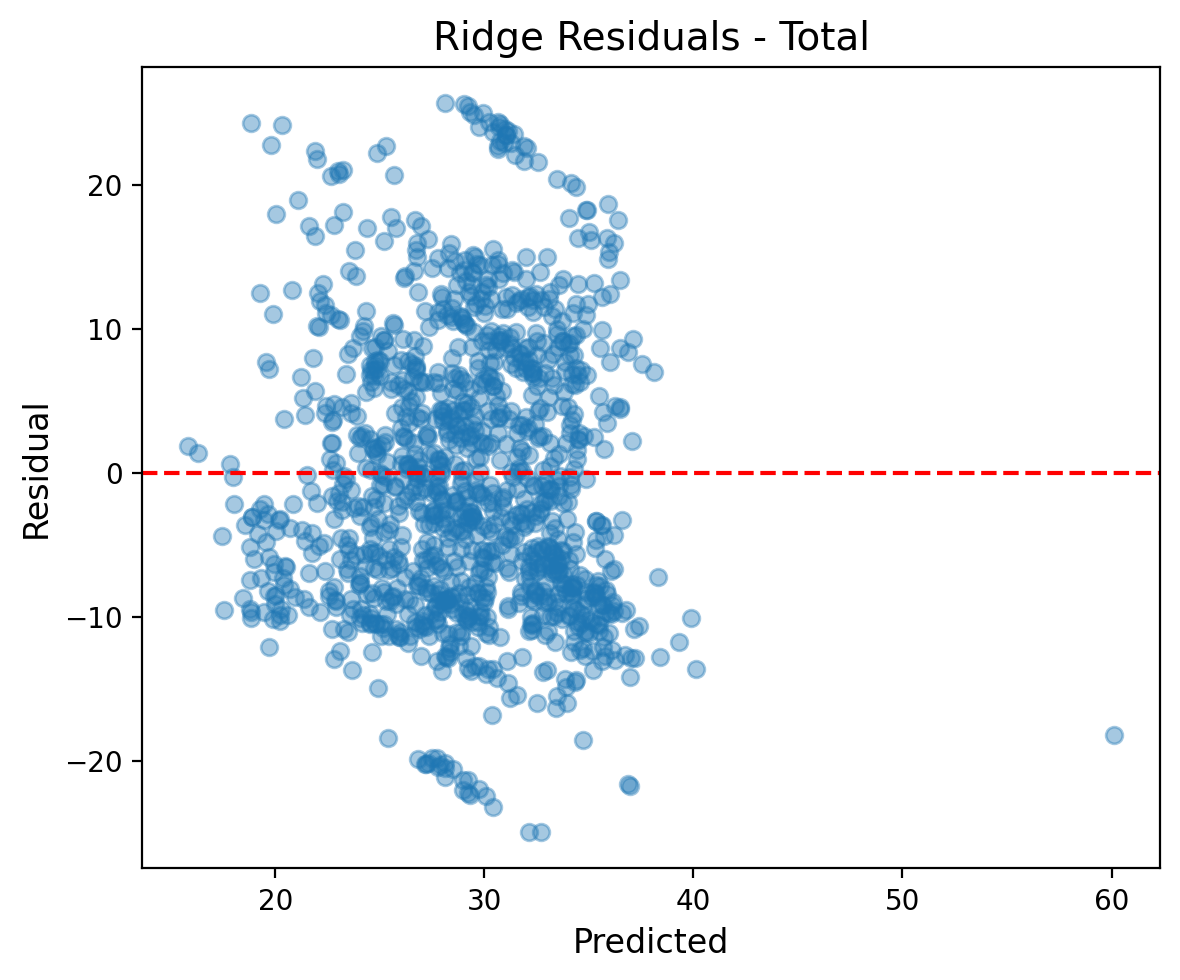

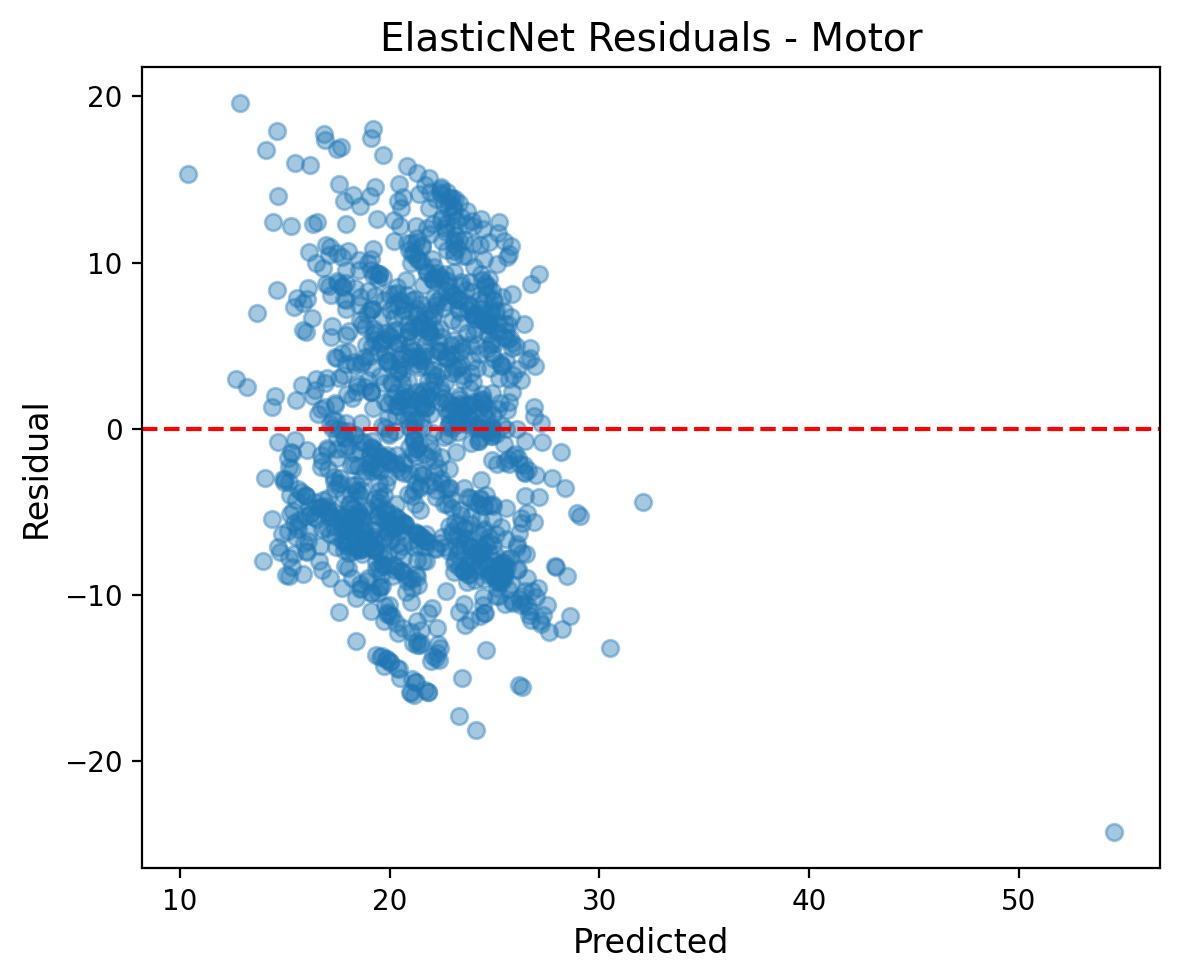

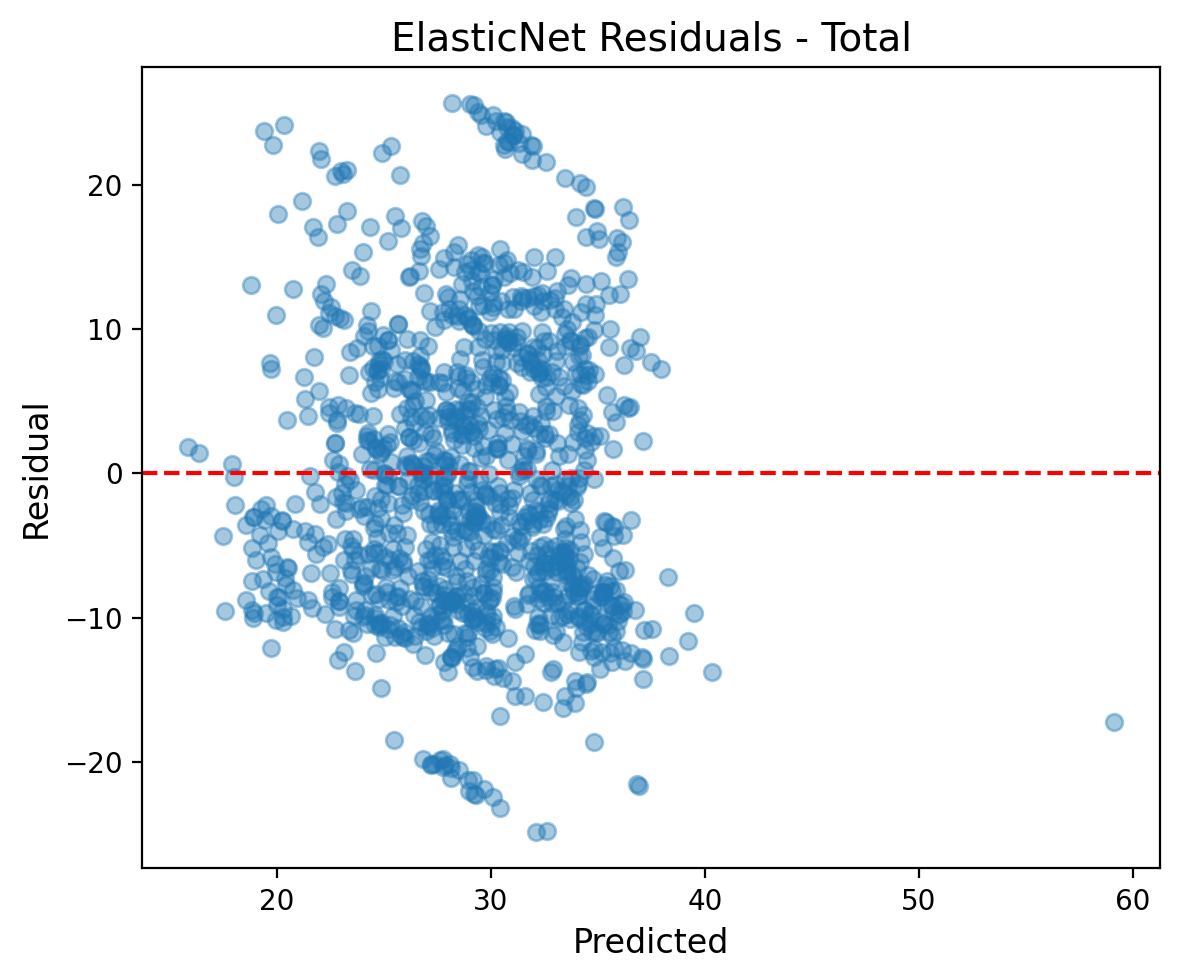

In [82]:
plot_residuals(y_test[:,0], moe_preds[:,0], "MoE Residuals - Motor")
plot_residuals(y_test[:,1], moe_preds[:,1], "MoE Residuals - Total")

plot_residuals(y_test[:,0], nn_preds[:,0], "NN Residuals - Motor")
plot_residuals(y_test[:,1], nn_preds[:,1], "NN Residuals - Total")

plot_residuals(y_test[:,0], rf_preds[:,0], "RF Residuals - Motor")
plot_residuals(y_test[:,1], rf_preds[:,1], "RF Residuals - Total")

plot_residuals(y_test[:,0], ridge_preds[:,0], "Ridge Residuals - Motor")
plot_residuals(y_test[:,1], ridge_preds[:,1], "Ridge Residuals - Total")

plot_residuals(y_test[:,0], enet_preds[:,0], "ElasticNet Residuals - Motor")
plot_residuals(y_test[:,1], enet_preds[:,1], "ElasticNet Residuals - Total")

In [83]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

with torch.no_grad():
    nn_test_scaled = nn_model(X_test_tensor).cpu().numpy()

rf_test_scaled = rf_expert.predict(X_test)
ridge_test_scaled = ridge_expert.predict(X_test)
enet_test_scaled = enet_expert.predict(X_test)

Z_test = np.hstack([
    nn_test_scaled,
    rf_test_scaled,
    ridge_test_scaled,
    enet_test_scaled
])

print("Z_test shape:", Z_test.shape)

Z_test shape: (1175, 8)


In [84]:
def plot_error_distribution(y_true, y_pred, title):
    errors = (y_true - y_pred).flatten()
    
    plt.figure(figsize=(6,4))
    sns.histplot(errors, bins=40, kde=True)
    plt.title(title)
    plt.xlabel("Prediction Error")
    plt.tight_layout()
    plt.savefig(f"../results/{title.replace(' ', '_').lower()}_error_distribution.png")
    plt.show()

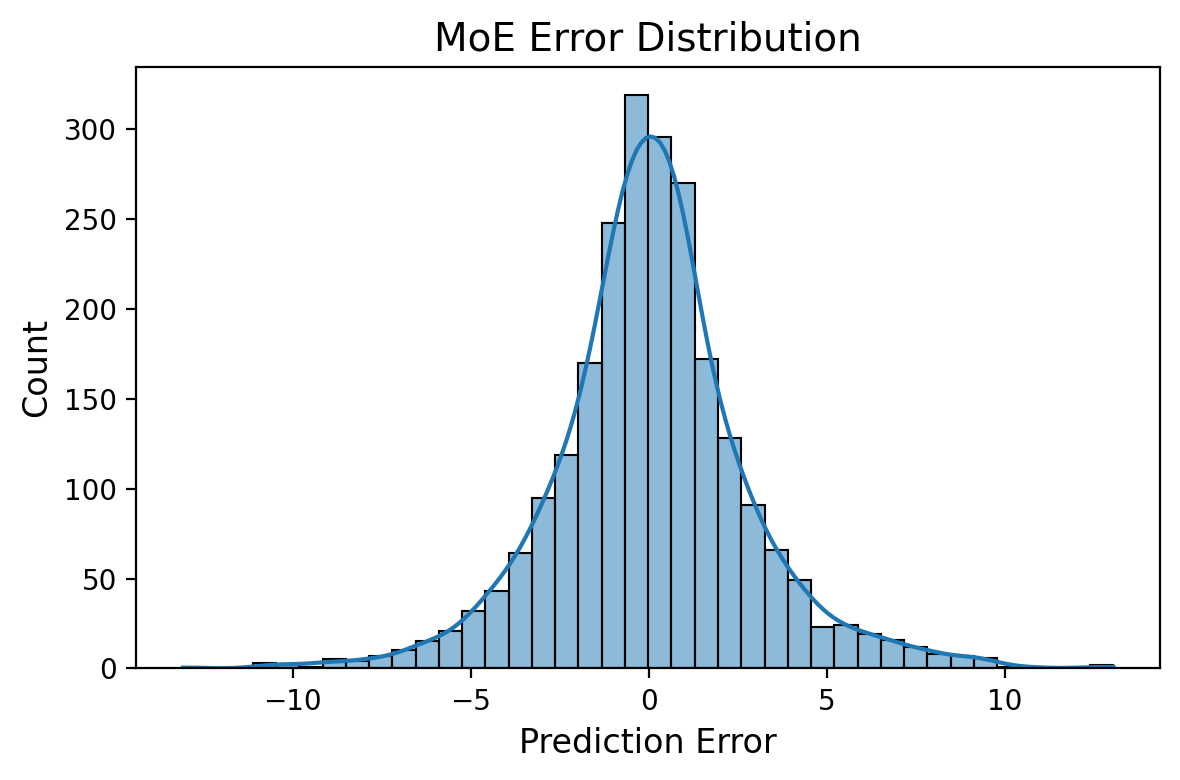

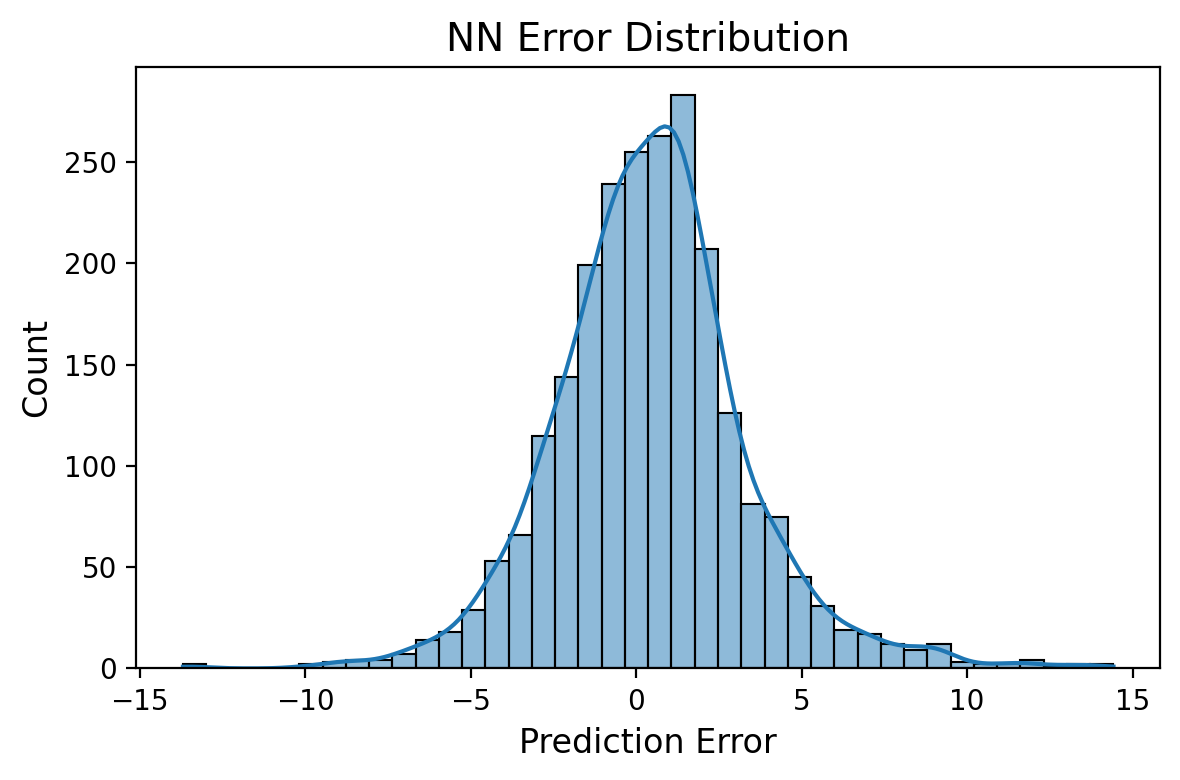

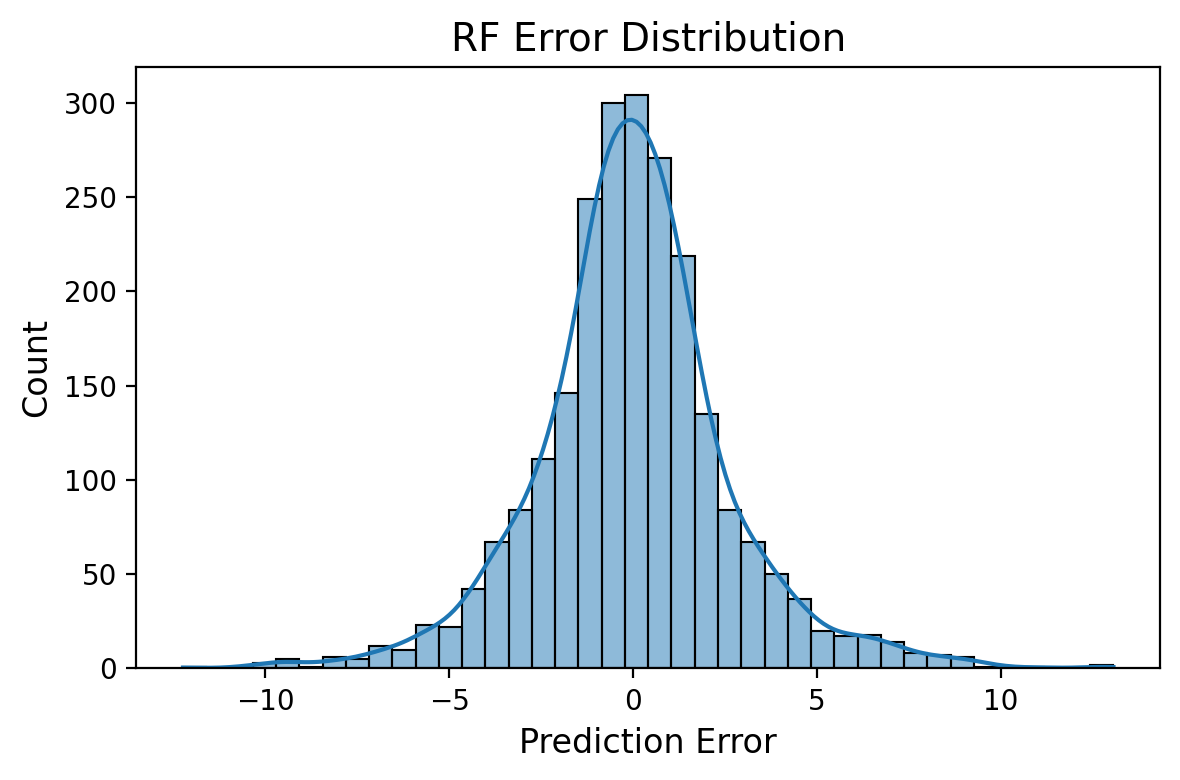

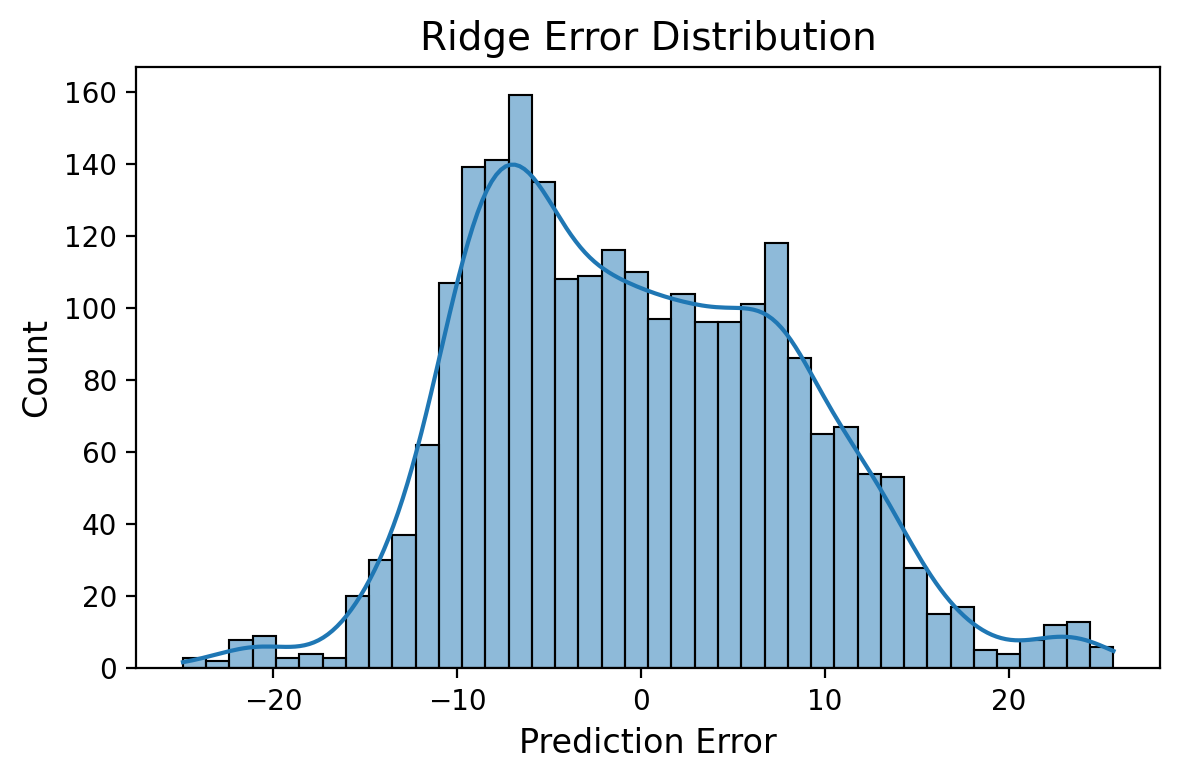

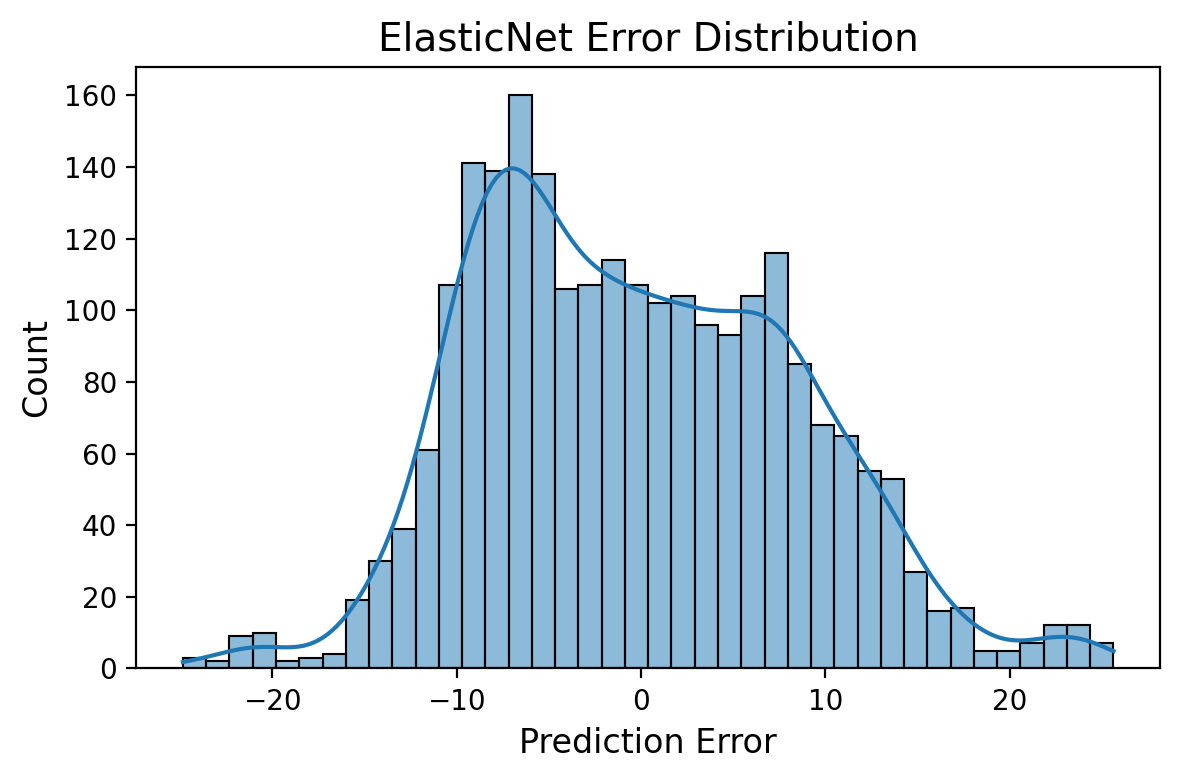

In [85]:
plot_error_distribution(y_test, moe_preds, "MoE Error Distribution")

plot_error_distribution(y_test, nn_preds, "NN Error Distribution")

plot_error_distribution(y_test, rf_preds, "RF Error Distribution")

plot_error_distribution(y_test, ridge_preds, "Ridge Error Distribution")

plot_error_distribution(y_test, enet_preds, "ElasticNet Error Distribution")

In [86]:
with torch.no_grad():
    weights_motor, weights_total = gate_model(
        torch.tensor(Z_test, dtype=torch.float32).to(DEVICE)
    )

weights_motor = weights_motor.cpu().numpy()
weights_total = weights_total.cpu().numpy()

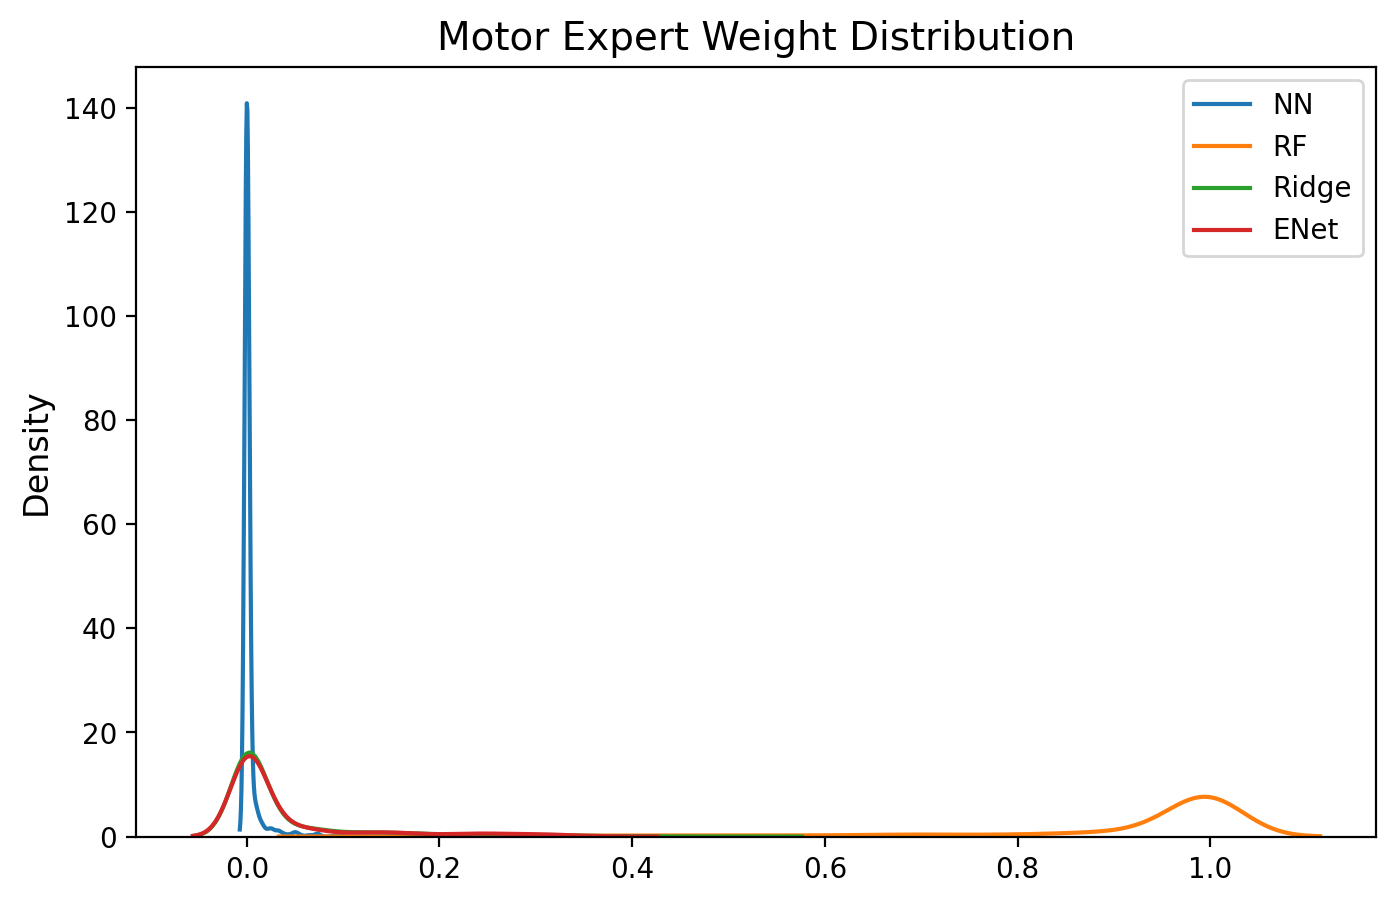

In [87]:
expert_names = ["NN", "RF", "Ridge", "ENet"]

plt.figure(figsize=(8,5))
for i in range(4):
    sns.kdeplot(weights_motor[:,i], label=expert_names[i])

plt.title("Motor Expert Weight Distribution")
plt.legend()
plt.savefig("../results/motor_expert_weight_distribution.png")
plt.show()

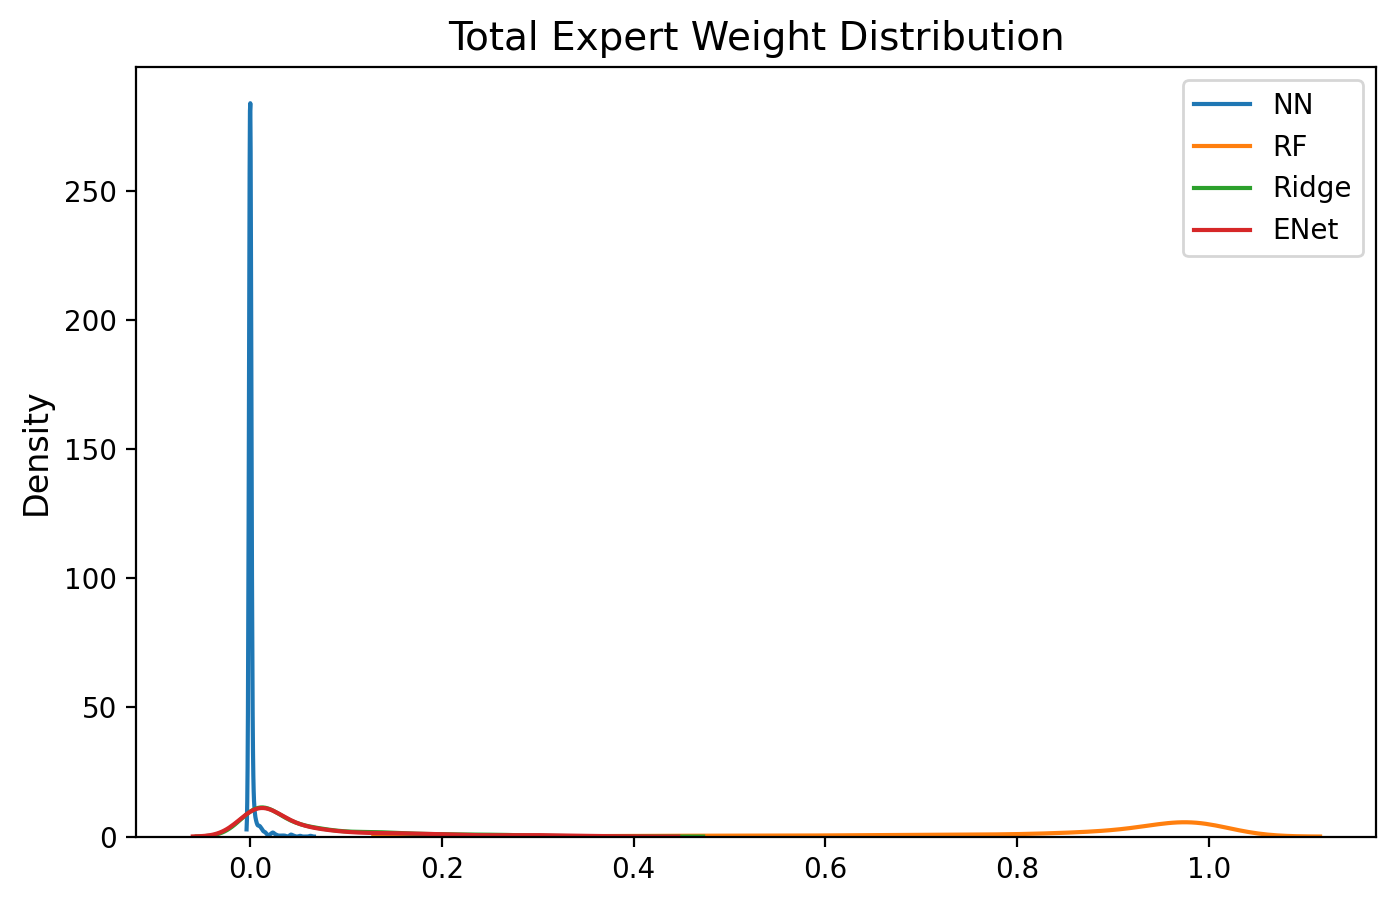

In [88]:
expert_names = ["NN", "RF", "Ridge", "ENet"]

plt.figure(figsize=(8,5))
for i in range(4):
    sns.kdeplot(weights_total[:,i], label=expert_names[i])

plt.title("Total Expert Weight Distribution")
plt.legend()
plt.savefig("../results/total_expert_weight_distribution.png")
plt.show()

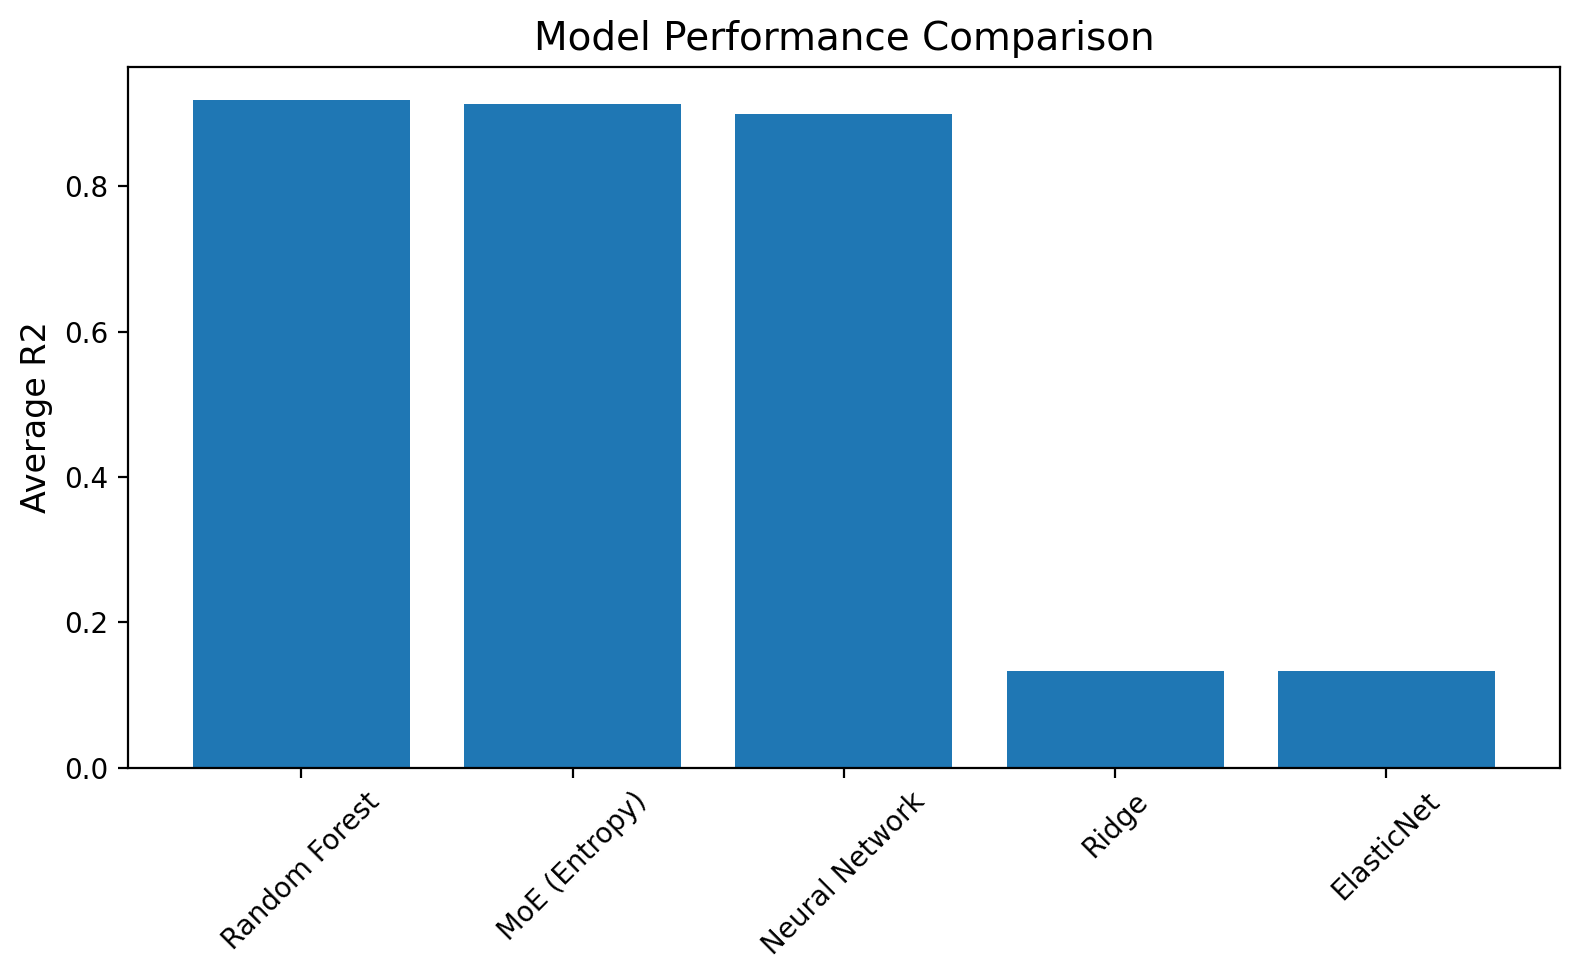

In [89]:
plt.figure(figsize=(8,5))

models = results_df["Model"]
avg_r2 = results_df["Avg R2"]

plt.bar(models, avg_r2)
plt.xticks(rotation=45)
plt.ylabel("Average R2")
plt.title("Model Performance Comparison")
plt.tight_layout()
plt.savefig("../results/model_performance_comparison.png")
plt.show()

In [92]:
import os
import pandas as pd
from reportlab.platypus import (
    SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, PageBreak
)
from reportlab.lib.styles import getSampleStyleSheet
from reportlab.lib import colors
from reportlab.lib.units import inch

# ===============================
# CONFIG
# ===============================

PLOTS_DIR = "../results"
OUTPUT_PATH = "../results/MoE_Model_Report_Grouped.pdf"
TABLE_CSV = os.path.join(PLOTS_DIR, "performance_comparison.csv")

os.makedirs("../results", exist_ok=True)

# ===============================
# GROUP DEFINITIONS
# ===============================

MODEL_GROUPS = {
    "Neural Network (NN)": "nn_",
    "Random Forest (RF)": "rf_",
    "Ridge Regression": "ridge",
    "Elastic Net": "elasticnet",
    "Mixture of Experts (MoE)": "moe_"
}

# ===============================
# CREATE DOCUMENT
# ===============================

doc = SimpleDocTemplate(OUTPUT_PATH)
elements = []
styles = getSampleStyleSheet()

# ===============================
# TITLE PAGE
# ===============================

elements.append(Paragraph("Mixture of Experts Model Report", styles["Heading1"]))
elements.append(Spacer(1, 0.3 * inch))
elements.append(Paragraph("Grouped Model Performance Analysis", styles["Heading2"]))
elements.append(PageBreak())

# ===============================
# ADD PERFORMANCE TABLE
# ===============================

if os.path.exists(TABLE_CSV):
    df = pd.read_csv(TABLE_CSV)

    elements.append(Paragraph("Model Performance Comparison", styles["Heading2"]))
    elements.append(Spacer(1, 0.2 * inch))

    table_data = [df.columns.tolist()] + df.values.tolist()
    table = Table(table_data, repeatRows=1)

    table.setStyle(TableStyle([
        ('BACKGROUND', (0, 0), (-1, 0), colors.lightgrey),
        ('GRID', (0, 0), (-1, -1), 0.5, colors.grey),
        ('ALIGN', (1, 1), (-1, -1), 'CENTER'),
    ]))

    elements.append(table)
    elements.append(PageBreak())

# ===============================
# GROUPED PLOTS
# ===============================

all_images = os.listdir(PLOTS_DIR)

for model_name, keyword in MODEL_GROUPS.items():

    model_images = sorted([f for f in all_images if keyword in f and f.endswith(".png")])

    if not model_images:
        continue

    elements.append(Paragraph(model_name, styles["Heading1"]))
    elements.append(Spacer(1, 0.3 * inch))

    for img_file in model_images:
        img_path = os.path.join(PLOTS_DIR, img_file)

        elements.append(Paragraph(img_file.replace("_", " "), styles["Normal"]))
        elements.append(Spacer(1, 0.2 * inch))

        img = Image(img_path)
        img.drawHeight = 5 * inch
        img.drawWidth = 6 * inch

        elements.append(img)
        elements.append(PageBreak())

# ===============================
# BUILD
# ===============================

doc.build(elements)

print(f"✅ Grouped PDF exported to: {OUTPUT_PATH}")

✅ Grouped PDF exported to: ../results/MoE_Model_Report_Grouped.pdf
